# 🏏 IPL 2026 Winner Prediction Model

---

**Author:** Shambhuraj Salunkhe  
**Date:** April 2026  
**Domain:** Sports Analytics | Machine Learning  

---

## 📋 Table of Contents

1. [Introduction](#1-introduction)
2. [Problem Statement](#2-problem-statement)
3. [Data Collection](#3-data-collection)
4. [Data Understanding](#4-data-understanding)
5. [Data Cleaning & Preprocessing](#5-data-cleaning--preprocessing)
6. [Feature Engineering](#6-feature-engineering)
7. [Exploratory Data Analysis (EDA)](#7-exploratory-data-analysis-eda)
8. [Model Building](#8-model-building)
9. [Model Evaluation](#9-model-evaluation)
10. [Prediction System](#10-prediction-system)
11. [Real-World Application](#11-real-world-application)
12. [Conclusion](#12-conclusion)
13. [Future Improvements](#13-future-improvements)

## 1. Introduction

The Indian Premier League (IPL) is one of the most celebrated and commercially successful Twenty20 cricket leagues in the world. Since its inception in 2008, the IPL has grown into a global sporting spectacle that attracts top cricketing talent from across the globe, combined with passionate fan engagement and significant financial investment from franchise owners, sponsors, and broadcasters. Each season, ten franchise teams compete in a gruelling round-robin and knockout format across multiple venues in India, delivering high-intensity cricket that captivates millions of viewers worldwide.

Predicting the outcome of IPL matches has long fascinated data scientists, cricket analysts, and sports enthusiasts alike. Unlike many other sports, cricket — and particularly the T20 format — is highly dynamic and influenced by a multitude of factors. A single over of explosive batting or a spell of disciplined bowling can completely alter the complexion of a match. Variables such as the toss outcome, the venue's characteristics (e.g., batting-friendly pitches versus bowler-friendly tracks), team composition, recent form, player availability, and even weather conditions contribute to the final result in ways that are often non-linear and complex.

In this notebook, we build a comprehensive Machine Learning pipeline to predict the winner of IPL 2026 matches. We leverage historical-like match data augmented with modern team and player performance metrics, apply rigorous data preprocessing and feature engineering techniques, and train and evaluate multiple classification models to identify the most accurate predictor. The goal is not only to build an accurate model but also to extract meaningful insights about what factors most significantly influence match outcomes in the IPL.

This project demonstrates the full lifecycle of a data science workflow — from data generation and exploration through feature engineering and model selection — and serves as a portfolio-ready piece that highlights proficiency in Python, pandas, scikit-learn, XGBoost, and data visualization libraries such as Matplotlib and Seaborn.

## 2. Problem Statement

The primary objective of this project is to develop a supervised machine learning classification model capable of predicting the winning team in an IPL T20 cricket match, given a set of pre-match and contextual features. Specifically, the model should accept inputs such as the two competing teams, the match venue, the toss winner, the toss decision (bat or field), along with derived performance metrics (team form, player strength scores, historical win ratios), and output the predicted winner with a reasonable degree of confidence.

This problem is formulated as a **binary classification** task for any given pair of teams: the model predicts whether Team A will win or Team B will win. By framing the problem this way, we can apply well-established classification algorithms and evaluation metrics.

### Key Challenges

- **Class Imbalance:** Historically dominant teams like Chennai Super Kings and Mumbai Indians may have significantly higher win counts, potentially biasing the model.
- **High Dimensionality after Encoding:** Categorical variables such as team names, venues, and toss decisions need to be encoded, which can inflate the feature space.
- **Non-linear Relationships:** The relationship between features and match outcomes is often non-linear (e.g., winning the toss does not guarantee winning the match).
- **Data Limitations:** Since we are simulating data for IPL 2026, the synthetic dataset must closely mirror realistic distributions and correlations found in actual IPL data.

### Success Criteria

The model should achieve an accuracy of **at least 65-75%** on the test set, which is considered a strong benchmark for sports prediction tasks. Additionally, we aim to identify the top features that drive predictions, providing actionable insights for analysts and fans.

## 3. Data Collection

For this project, we construct a **realistic synthetic dataset** that closely mimics the statistical distributions and patterns observed in historical IPL match data from 2008–2025. The dataset is generated programmatically using controlled randomization to ensure that key relationships — such as the advantage of batting first on certain grounds, the correlation between team strength and wins, and the impact of the toss — are preserved.

Each record in the dataset represents a single match and contains the following information:

- **Team-level identifiers:** Names of the two competing teams
- **Match context:** Venue, toss winner, toss decision
- **Performance metrics:** Batting first team, bowling first team, team form (last 5 matches), player strength scores
- **Derived features:** Home advantage flag, win ratios, recent performance scores
- **Target variable:** The actual winner of the match

The dataset is designed to contain approximately **800–1000 match records** spanning all ten IPL franchises, providing sufficient data volume for training robust machine learning models while maintaining realistic class distributions and feature correlations.

## 4. Data Understanding

Before diving into preprocessing and modeling, it is essential to develop a thorough understanding of the dataset's structure, distributions, and potential quality issues. In this section, we load the dataset, inspect its shape and data types, examine summary statistics for numerical and categorical features, and identify any anomalies such as missing values or duplicated records.

This exploratory step informs our preprocessing strategy and helps us make informed decisions about encoding schemes, scaling methods, and feature engineering opportunities. A solid understanding of the data is the foundation upon which every subsequent step in the pipeline is built.

### 4.1 Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import datetime

# Scikit-learn imports
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)

# XGBoost
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Set visualization styles
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
COLORS = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7',
          '#DDA0DD', '#98D8C8', '#F7DC6F', '#BB8FCE', '#85C1E9']

print("✅ All libraries imported successfully!")
if XGBOOST_AVAILABLE:
    print("✅ XGBoost is available!")
else:
    print("⚠️ XGBoost not available. GradientBoosting will be used instead.")

✅ All libraries imported successfully!
✅ XGBoost is available!


### 3.1 Generate Synthetic IPL Dataset

We now generate a comprehensive synthetic dataset that closely mirrors real IPL match statistics. The generation process incorporates realistic probability distributions for team strengths, venue characteristics, and the complex interplay between toss outcomes and match results. Each team is assigned a base strength parameter that reflects its historical competitiveness, and match outcomes are generated through a probabilistic model that accounts for team strength differential, home advantage, toss impact, and random variance.

In [2]:
# ============================================================
# IPL 2026 DATASET GENERATION
# ============================================================

# Define IPL teams for 2026 season
TEAMS = [
    'Chennai Super Kings', 'Mumbai Indians', 'Royal Challengers Bengaluru',
    'Kolkata Knight Riders', 'Delhi Capitals', 'Rajasthan Royals',
    'Punjab Kings', 'Sunrisers Hyderabad', 'Gujarat Titans',
    'Lucknow Super Giants'
]

# Abbreviations
TEAM_ABBR = {
    'Chennai Super Kings': 'CSK', 'Mumbai Indians': 'MI',
    'Royal Challengers Bengaluru': 'RCB', 'Kolkata Knight Riders': 'KKR',
    'Delhi Capitals': 'DC', 'Rajasthan Royals': 'RR',
    'Punjab Kings': 'PBKS', 'Sunrisers Hyderabad': 'SRH',
    'Gujarat Titans': 'GT', 'Lucknow Super Giants': 'LSG'
}

# Venues with home team mapping
VENUES = {
    'M. A. Chidambaram Stadium, Chennai': 'Chennai Super Kings',
    'Wankhede Stadium, Mumbai': 'Mumbai Indians',
    'M. Chinnaswamy Stadium, Bengaluru': 'Royal Challengers Bengaluru',
    'Eden Gardens, Kolkata': 'Kolkata Knight Riders',
    'Arun Jaitley Stadium, Delhi': 'Delhi Capitals',
    'Sawai Mansingh Stadium, Jaipur': 'Rajasthan Royals',
    'Punjab Cricket Association Stadium, Mohali': 'Punjab Kings',
    'Rajiv Gandhi International Stadium, Hyderabad': 'Sunrisers Hyderabad',
    'Narendra Modi Stadium, Ahmedabad': 'Gujarat Titans',
    'Ekana Cricket Stadium, Lucknow': 'Lucknow Super Giants',
    'DY Patil Stadium, Navi Mumbai': None,
    'Brabourne Stadium, Mumbai': None,
    'Maharashtra Cricket Association Stadium, Pune': None,
    'ACA-VDCA Stadium, Visakhapatnam': None,
    'Shaheed Veer Narayan Singh International Stadium, Raipur': None
}

# Team base strength (historical-like: higher = stronger)
TEAM_STRENGTH = {
    'Chennai Super Kings': 0.82, 'Mumbai Indians': 0.80,
    'Kolkata Knight Riders': 0.75, 'Royal Challengers Bengaluru': 0.72,
    'Sunrisers Hyderabad': 0.70, 'Rajasthan Royals': 0.68,
    'Gujarat Titans': 0.74, 'Delhi Capitals': 0.65,
    'Punjab Kings': 0.60, 'Lucknow Super Giants': 0.66
}

np.random.seed(42)

def generate_team_form(team, n_matches=5):
    """Generate recent form as number of wins in last 5 matches."""
    base_win_prob = TEAM_STRENGTH[team]
    wins = sum(1 for _ in range(n_matches) if np.random.random() < base_win_prob)
    return wins

def generate_player_strength(team):
    """Generate composite player strength score for a team."""
    base = TEAM_STRENGTH[team]
    batting = np.clip(np.random.normal(base * 85, 8), 40, 100)
    bowling = np.clip(np.random.normal(base * 80, 9), 35, 100)
    fielding = np.clip(np.random.normal(base * 78, 7), 35, 100)
    allround = np.clip(np.random.normal(base * 75, 10), 30, 100)
    overall = round(0.35 * batting + 0.30 * bowling + 0.15 * fielding + 0.20 * allround, 1)
    return {'Batting Strength': round(batting, 1), 'Bowling Strength': round(bowling, 1),
            'Fielding Strength': round(fielding, 1), 'Allround Strength': round(allround, 1),
            'Overall Strength': overall}

def compute_win_probability(team1, team2, venue, toss_winner, toss_decision):
    """Compute probability of team1 winning based on multiple factors."""
    s1 = TEAM_STRENGTH[team1]
    s2 = TEAM_STRENGTH[team2]
    
    # Base probability from strength
    prob = 1 / (1 + np.exp(-5 * (s1 - s2)))
    
    # Home advantage (+5% if home venue)
    home_team = VENUES.get(venue)
    if home_team == team1:
        prob += 0.05
    elif home_team == team2:
        prob -= 0.05
    
    # Toss advantage (+3%)
    if toss_winner == team1:
        prob += 0.03
    elif toss_winner == team2:
        prob -= 0.03
    
    # Toss decision at venue (batting first advantage on some grounds)
    bat_first_venues = ['M. Chinnaswamy Stadium, Bengaluru',
                        'Wankhede Stadium, Mumbai',
                        'M. A. Chidambaram Stadium, Chennai']
    if toss_decision == 'bat' and venue in bat_first_venues and toss_winner == team1:
        prob += 0.03
    elif toss_decision == 'field' and venue not in bat_first_venues and toss_winner == team1:
        prob += 0.02
    
    return np.clip(prob, 0.15, 0.85)

def generate_dataset(n_matches=950):
    """Generate the full synthetic IPL match dataset."""
    records = []
    match_id = 1
    
    for _ in range(n_matches):
        # Pick two different teams
        team1, team2 = np.random.choice(TEAMS, size=2, replace=False)
        venue = np.random.choice(list(VENUES.keys()))
        
        # Toss
        toss_winner = np.random.choice([team1, team2])
        toss_decision = np.random.choice(['bat', 'field'], p=[0.40, 0.60])
        
        # Batting/bowling order
        if toss_decision == 'bat':
            batting_first = toss_winner
            bowling_first = team2 if toss_winner == team1 else team1
        else:
            bowling_first = toss_winner
            batting_first = team2 if toss_winner == team1 else team1
        
        # Team form
        team1_form = generate_team_form(team1)
        team2_form = generate_team_form(team2)
        
        # Player strengths
        team1_stats = generate_player_strength(team1)
        team2_stats = generate_player_strength(team2)
        
        # Home advantage
        home_team = VENUES.get(venue)
        team1_home = 1 if home_team == team1 else (0 if home_team == team2 else 0)
        team2_home = 1 if home_team == team2 else (0 if home_team == team1 else 0)
        
        # Win probability and outcome
        win_prob = compute_win_probability(team1, team2, venue, toss_winner, toss_decision)
        winner = team1 if np.random.random() < win_prob else team2
        
        # Win margin (runs for bat-first wins, wickets for chase wins)
        if winner == batting_first:
            win_margin = np.random.randint(1, 60)
            win_type = 'runs'
        else:
            win_margin = np.random.randint(1, 10)
            win_type = 'wickets'
        
        # First innings score
        first_innings_score = np.random.randint(120, 230)
        
        # Season
        season = np.random.randint(2016, 2026)
        
        record = {
            'Match_ID': match_id,
            'Season': season,
            'Team1': team1,
            'Team2': team2,
            'Venue': venue,
            'Toss_Winner': toss_winner,
            'Toss_Decision': toss_decision,
            'Batting_First': batting_first,
            'Bowling_First': bowling_first,
            'Team1_Form_Last5': team1_form,
            'Team2_Form_Last5': team2_form,
            'Team1_Batting_Str': team1_stats['Batting Strength'],
            'Team1_Bowling_Str': team1_stats['Bowling Strength'],
            'Team1_Fielding_Str': team1_stats['Fielding Strength'],
            'Team1_Allround_Str': team1_stats['Allround Strength'],
            'Team1_Overall_Str': team1_stats['Overall Strength'],
            'Team2_Batting_Str': team2_stats['Batting Strength'],
            'Team2_Bowling_Str': team2_stats['Bowling Strength'],
            'Team2_Fielding_Str': team2_stats['Fielding Strength'],
            'Team2_Allround_Str': team2_stats['Allround Strength'],
            'Team2_Overall_Str': team2_stats['Overall Strength'],
            'Team1_Home': team1_home,
            'Team2_Home': team2_home,
            'First_Innings_Score': first_innings_score,
            'Win_Margin': win_margin,
            'Win_Type': win_type,
            'Winner': winner
        }
        records.append(record)
        match_id += 1
    
    return pd.DataFrame(records)

# Generate the dataset
df = generate_dataset(n_matches=950)
print(f"Dataset generated successfully with {df.shape[0]} matches and {df.shape[1]} features.")
print(f"\nSeasons covered: {df['Season'].min()} - {df['Season'].max()}")
print(f"Teams: {df['Team1'].nunique()} franchises")
print(f"Venues: {df['Venue'].nunique()} grounds")

Dataset generated successfully with 950 matches and 27 features.

Seasons covered: 2016 - 2025
Teams: 10 franchises
Venues: 15 grounds


### 4.2 Dataset Overview

In [3]:
# Display first few rows
display(df.head(10))

,Match_ID,Season,Team1,Team2,Venue,Toss_Winner,Toss_Decision,Batting_First,Bowling_First,Team1_Form_Last5,...,Team2_Bowling_Str,Team2_Fielding_Str,Team2_Allround_Str,Team2_Overall_Str,Team1_Home,Team2_Home,First_Innings_Score,Win_Margin,Win_Type,Winner
0,1,2022,Gujarat Titans,Mumbai Indians,"M. Chinnaswamy Stadium, Bengaluru",Gujarat Titans,bat,Gujarat Titans,Mumbai Indians,3,...,57.3,57.5,38.6,56.1,0,0,227,3,wickets,Mumbai Indians
1,2,2025,Lucknow Super Giants,Mumbai Indians,"Eden Gardens, Kolkata",Lucknow Super Giants,field,Mumbai Indians,Lucknow Super Giants,3,...,71.9,55.3,44.2,63.1,0,0,143,5,wickets,Lucknow Super Giants
2,3,2016,Mumbai Indians,Kolkata Knight Riders,"Rajiv Gandhi International Stadium, Hyderabad",Mumbai Indians,bat,Mumbai Indians,Kolkata Knight Riders,4,...,72.2,58.0,66.3,68.2,0,0,122,14,runs,Mumbai Indians
3,4,2022,Lucknow Super Giants,Mumbai Indians,"Ekana Cricket Stadium, Lucknow",Mumbai Indians,bat,Mumbai Indians,Lucknow Super Giants,4,...,68.6,63.1,69.7,66.3,1,0,208,28,runs,Mumbai Indians
4,5,2025,Mumbai Indians,Punjab Kings,"M. Chinnaswamy Stadium, Bengaluru",Mumbai Indians,bat,Mumbai Indians,Punjab Kings,5,...,47.2,55.5,30.7,45.3,0,0,163,53,runs,Mumbai Indians
5,6,2018,Sunrisers Hyderabad,Mumbai Indians,"Rajiv Gandhi International Stadium, Hyderabad",Sunrisers Hyderabad,field,Mumbai Indians,Sunrisers Hyderabad,4,...,77.9,56.9,56.8,64.5,1,0,161,30,runs,Mumbai Indians
6,7,2020,Lucknow Super Giants,Royal Challengers Bengaluru,"Arun Jaitley Stadium, Delhi",Lucknow Super Giants,field,Royal Challengers Bengaluru,Lucknow Super Giants,2,...,40.2,57.2,53.8,52.4,0,0,152,4,wickets,Lucknow Super Giants
7,8,2020,Rajasthan Royals,Mumbai Indians,"Brabourne Stadium, Mumbai",Rajasthan Royals,bat,Rajasthan Royals,Mumbai Indians,3,...,70.4,65.7,59.3,66.0,0,0,182,1,wickets,Mumbai Indians
8,9,2018,Delhi Capitals,Kolkata Knight Riders,"Ekana Cricket Stadium, Lucknow",Delhi Capitals,field,Kolkata Knight Riders,Delhi Capitals,4,...,67.8,68.6,56.3,64.3,0,0,135,46,runs,Kolkata Knight Riders
9,10,2022,Delhi Capitals,Kolkata Knight Riders,"ACA-VDCA Stadium, Visakhapatnam",Delhi Capitals,field,Kolkata Knight Riders,Delhi Capitals,4,...,55.6,69.7,51.9,59.5,0,0,181,5,wickets,Delhi Capitals


### 4.3 Dataset Shape & Data Types

In [4]:
print(f"Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns\n")
print("=" * 60)
print("DATA TYPES:")
print("=" * 60)
print(df.dtypes)
print("\n" + "=" * 60)
print("MEMORY USAGE:")
print("=" * 60)
print(f"Total Memory: {df.memory_usage(deep=True).sum() / 1024:.1f} KB")

Dataset Shape: 950 rows × 27 columns

DATA TYPES:
Match_ID                 int64
Season                   int64
Team1                   object
Team2                   object
Venue                   object
Toss_Winner             object
Toss_Decision           object
Batting_First           object
Bowling_First           object
Team1_Form_Last5         int64
Team2_Form_Last5         int64
Team1_Batting_Str      float64
Team1_Bowling_Str      float64
Team1_Fielding_Str     float64
Team1_Allround_Str     float64
Team1_Overall_Str      float64
Team2_Batting_Str      float64
Team2_Bowling_Str      float64
Team2_Fielding_Str     float64
Team2_Allround_Str     float64
Team2_Overall_Str      float64
Team1_Home               int64
Team2_Home               int64
First_Innings_Score      int64
Win_Margin               int64
Win_Type                object
Winner                  object
dtype: object

MEMORY USAGE:
Total Memory: 859.1 KB


### 4.4 Statistical Summary

In [5]:
# Numerical features summary
print("=" * 60)
print("NUMERICAL FEATURES SUMMARY:")
print("=" * 60)
display(df.describe().T.round(2))

NUMERICAL FEATURES SUMMARY:


,count,mean,std,min,25%,50%,75%,max
Match_ID,950.0,475.50,274.39,1.0,238.25,475.50,712.75,950.0
Season,950.0,2020.47,2.83,2016.0,2018.00,2021.00,2023.00,2025.0
Team1_Form_Last5,950.0,3.55,1.04,0.0,3.00,4.00,4.00,5.0
Team2_Form_Last5,950.0,3.58,1.05,0.0,3.00,4.00,4.00,5.0
Team1_Batting_Str,950.0,60.84,9.61,40.0,54.00,61.00,67.47,87.2
Team1_Bowling_Str,950.0,56.91,10.32,35.0,49.90,56.70,63.60,87.0
Team1_Fielding_Str,950.0,55.41,8.37,35.0,49.80,55.40,61.20,76.8
Team1_Allround_Str,950.0,53.28,11.09,30.0,45.20,53.70,61.20,81.6
Team1_Overall_Str,950.0,57.33,6.81,37.7,52.40,57.40,62.00,77.5
Team2_Batting_Str,950.0,60.70,9.61,40.0,54.20,60.75,67.20,90.4


In [6]:
# Categorical features summary
print("=" * 60)
print("CATEGORICAL FEATURES SUMMARY:")
print("=" * 60)
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    print(f"\n📌 {col}:")
    print(f"   Unique values: {df[col].nunique()}")
    print(f"   Most frequent: {df[col].mode()[0]} ({df[col].value_counts().iloc[0]} occurrences)")

CATEGORICAL FEATURES SUMMARY:

📌 Team1:
   Unique values: 10
   Most frequent: Sunrisers Hyderabad (117 occurrences)

📌 Team2:
   Unique values: 10
   Most frequent: Royal Challengers Bengaluru (108 occurrences)

📌 Venue:
   Unique values: 15
   Most frequent: Punjab Cricket Association Stadium, Mohali (77 occurrences)

📌 Toss_Winner:
   Unique values: 10
   Most frequent: Sunrisers Hyderabad (111 occurrences)

📌 Toss_Decision:
   Unique values: 2
   Most frequent: field (578 occurrences)

📌 Batting_First:
   Unique values: 10
   Most frequent: Punjab Kings (111 occurrences)

📌 Bowling_First:
   Unique values: 10
   Most frequent: Sunrisers Hyderabad (128 occurrences)

📌 Win_Type:
   Unique values: 2
   Most frequent: wickets (479 occurrences)

📌 Winner:
   Unique values: 10
   Most frequent: Chennai Super Kings (115 occurrences)


### 4.5 Missing Values Check

In [7]:
print("=" * 60)
print("MISSING VALUES ANALYSIS:")
print("=" * 60)
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]
if missing_df.empty:
    print("✅ No missing values found in the dataset!")
else:
    display(missing_df)

MISSING VALUES ANALYSIS:
✅ No missing values found in the dataset!


### 4.6 Duplicate Records Check

In [8]:
duplicates = df.duplicated().sum()
print(f"Duplicate records: {duplicates}")
if duplicates > 0:
    df.drop_duplicates(inplace=True)
    print(f"Duplicates removed. New shape: {df.shape}")
else:
    print("✅ No duplicate records found.")

Duplicate records: 0
✅ No duplicate records found.


## 5. Data Cleaning & Preprocessing

Data cleaning is a critical step in any machine learning pipeline. In this section, we handle missing values (if any), remove or fix inconsistencies, encode categorical variables into numerical representations suitable for ML algorithms, and scale numerical features to ensure consistent magnitudes across the feature space. Proper preprocessing directly impacts model performance and reliability.

Our preprocessing strategy includes:
1. **Label Encoding** for ordinal categorical variables (e.g., Win_Type, Toss_Decision)
2. **One-Hot Encoding** for nominal categorical variables (e.g., Team names, Venues)
3. **Standard Scaling** for numerical features to normalize distributions
4. **Target Encoding** for the Winner variable (binary classification)

In [9]:
# ============================================================
# DATA CLEANING & PREPROCESSING
# ============================================================

# Create a working copy
df_clean = df.copy()

# Drop Match_ID as it has no predictive value
df_clean.drop('Match_ID', axis=1, inplace=True)

# --- Label Encoding for ordinal/binary categories ---
label_encoders = {}

# Encode Toss_Decision: 'bat' = 0, 'field' = 1
toss_decision_map = {'bat': 0, 'field': 1}
df_clean['Toss_Decision_Encoded'] = df_clean['Toss_Decision'].map(toss_decision_map)

# Encode Win_Type: 'runs' = 0, 'wickets' = 1
win_type_map = {'runs': 0, 'wickets': 1}
df_clean['Win_Type_Encoded'] = df_clean['Win_Type'].map(win_type_map)

# Encode Team names using LabelEncoder
team_cols = ['Team1', 'Team2', 'Toss_Winner', 'Batting_First', 'Bowling_First', 'Winner']
for col in team_cols:
    le = LabelEncoder()
    df_clean[f'{col}_Encoded'] = le.fit_transform(df_clean[col])
    label_encoders[col] = le

# Encode Venue
venue_le = LabelEncoder()
df_clean['Venue_Encoded'] = venue_le.fit_transform(df_clean['Venue'])
label_encoders['Venue'] = venue_le

print("✅ All categorical variables encoded successfully!")
print(f"\nEncoded columns added: {[c for c in df_clean.columns if 'Encoded' in c]}")

# --- Verify encoding ---
print(f"\nToss_Decision mapping: {toss_decision_map}")
print(f"Win_Type mapping: {win_type_map}")
print(f"\nTeam encoding (Winner):")
for idx, team in enumerate(label_encoders['Winner'].classes_):
    print(f"  {team} → {idx}")

✅ All categorical variables encoded successfully!

Encoded columns added: ['Toss_Decision_Encoded', 'Win_Type_Encoded', 'Team1_Encoded', 'Team2_Encoded', 'Toss_Winner_Encoded', 'Batting_First_Encoded', 'Bowling_First_Encoded', 'Winner_Encoded', 'Venue_Encoded']

Toss_Decision mapping: {'bat': 0, 'field': 1}
Win_Type mapping: {'runs': 0, 'wickets': 1}

Team encoding (Winner):
  Chennai Super Kings → 0
  Delhi Capitals → 1
  Gujarat Titans → 2
  Kolkata Knight Riders → 3
  Lucknow Super Giants → 4
  Mumbai Indians → 5
  Punjab Kings → 6
  Rajasthan Royals → 7
  Royal Challengers Bengaluru → 8
  Sunrisers Hyderabad → 9


### 5.1 Feature Scaling

In [10]:
# Identify numerical columns to scale (exclude encoded and target columns)
numerical_features = [
    'Team1_Form_Last5', 'Team2_Form_Last5',
    'Team1_Batting_Str', 'Team1_Bowling_Str', 'Team1_Fielding_Str',
    'Team1_Allround_Str', 'Team1_Overall_Str',
    'Team2_Batting_Str', 'Team2_Bowling_Str', 'Team2_Fielding_Str',
    'Team2_Allround_Str', 'Team2_Overall_Str',
    'First_Innings_Score', 'Win_Margin', 'Season'
]

# Initialize scaler
scaler = StandardScaler()
df_clean[numerical_features] = scaler.fit_transform(df_clean[numerical_features])

print("✅ Numerical features scaled using StandardScaler.")
print(f"Scaled features: {len(numerical_features)}")

✅ Numerical features scaled using StandardScaler.
Scaled features: 15


## 6. Feature Engineering

Feature engineering is often described as the art and science of extracting additional information from existing data to improve model performance. In the context of IPL match prediction, domain knowledge of cricket plays a crucial role in designing meaningful features that capture the nuances of the game.

In this section, we create several advanced features:

- **Win Ratio:** Historical win percentage for each team (simulated)
- **Strength Differential:** Difference in overall team strength scores
- **Toss Advantage Flag:** Whether the toss winner also won the match
- **Batting Strength Differential:** Difference between batting strengths
- **Bowling Strength Differential:** Difference between bowling strengths
- **Recent Performance Score:** Combined form score for both teams
- **Home Advantage Combined:** Net home advantage indicator
- **Chase Advantage:** Whether a team is chasing (bowling first)
- **Venue Batting-Friendly Flag:** Indicator for high-scoring venues

In [11]:
# ============================================================
# FEATURE ENGINEERING
# ============================================================

# --- 1. Simulated Historical Win Ratio ---
# Compute from the dataset itself as a proxy for historical performance
team_wins = df_clean.groupby('Winner_Encoded').size()
team_total = df_clean.groupby('Team1_Encoded').size() + df_clean.groupby('Team2_Encoded').size()
team_total = team_total.add(df_clean.groupby('Team2_Encoded').size(), fill_value=0)
# Simpler: just use count of appearances
team1_appearances = df_clean['Team1_Encoded'].value_counts().sort_index()
team2_appearances = df_clean['Team2_Encoded'].value_counts().sort_index()
total_appearances = team1_appearances.add(team2_appearances, fill_value=0).sort_index()
win_ratio = (team_wins / total_appearances).fillna(0.5)

df_clean['Team1_Win_Ratio'] = df_clean['Team1_Encoded'].map(win_ratio).fillna(0.5)
df_clean['Team2_Win_Ratio'] = df_clean['Team2_Encoded'].map(win_ratio).fillna(0.5)

# --- 2. Strength Differential ---
df_clean['Strength_Differential'] = df_clean['Team1_Overall_Str'] - df_clean['Team2_Overall_Str']

# --- 3. Batting Strength Differential ---
df_clean['Batting_Str_Diff'] = df_clean['Team1_Batting_Str'] - df_clean['Team2_Batting_Str']

# --- 4. Bowling Strength Differential ---
df_clean['Bowling_Str_Diff'] = df_clean['Team1_Bowling_Str'] - df_clean['Team2_Bowling_Str']

# --- 5. Form Differential ---
df_clean['Form_Differential'] = df_clean['Team1_Form_Last5'] - df_clean['Team2_Form_Last5']

# --- 6. Toss Advantage Flag (1 if toss_winner == team1) ---
df_clean['Team1_Won_Toss'] = (df_clean['Toss_Winner_Encoded'] == df_clean['Team1_Encoded']).astype(int)

# --- 7. Recent Performance Score ---
df_clean['Team1_Performance_Score'] = (df_clean['Team1_Win_Ratio'] * 0.4 +
                                        df_clean['Team1_Overall_Str'] * 0.3 +
                                        df_clean['Team1_Form_Last5'] / 5 * 0.3)
df_clean['Team2_Performance_Score'] = (df_clean['Team2_Win_Ratio'] * 0.4 +
                                        df_clean['Team2_Overall_Str'] * 0.3 +
                                        df_clean['Team2_Form_Last5'] / 5 * 0.3)
df_clean['Performance_Score_Diff'] = df_clean['Team1_Performance_Score'] - df_clean['Team2_Performance_Score']

# --- 8. Home Advantage Combined ---
df_clean['Home_Advantage'] = df_clean['Team1_Home'] - df_clean['Team2_Home']

# --- 9. Chase Advantage (team bowling first = chasing) ---
df_clean['Team1_Chasing'] = (df_clean['Bowling_First_Encoded'] == df_clean['Team1_Encoded']).astype(int)

# --- 10. Venue type indicator (high scoring venue) ---
high_scoring_venues = ['M. Chinnaswamy Stadium, Bengaluru', 'Wankhede Stadium, Mumbai',
                       'M. A. Chidambaram Stadium, Chennai']
df_clean['High_Scoring_Venue'] = df_clean['Venue'].isin(high_scoring_venues).astype(int)

# --- 11. Net Toss + Home Advantage ---
df_clean['Net_Advantage'] = df_clean['Team1_Won_Toss'] + df_clean['Home_Advantage']

# --- 12. Allround Differential ---
df_clean['Allround_Str_Diff'] = df_clean['Team1_Allround_Str'] - df_clean['Team2_Allround_Str']

print("✅ Feature engineering completed!")
print(f"Original features: {df.shape[1]}")
print(f"New features added: 12")
print(f"Total features now: {df_clean.shape[1]}")
print(f"\nNew engineered features:")
new_features = ['Team1_Win_Ratio', 'Team2_Win_Ratio', 'Strength_Differential',
                'Batting_Str_Diff', 'Bowling_Str_Diff', 'Form_Differential',
                'Team1_Won_Toss', 'Team1_Performance_Score', 'Team2_Performance_Score',
                'Performance_Score_Diff', 'Home_Advantage', 'Team1_Chasing',
                'High_Scoring_Venue', 'Net_Advantage', 'Allround_Str_Diff']
for f in new_features:
    if f in df_clean.columns:
        print(f"  ✓ {f}")

✅ Feature engineering completed!
Original features: 27
New features added: 12
Total features now: 50

New engineered features:
  ✓ Team1_Win_Ratio
  ✓ Team2_Win_Ratio
  ✓ Strength_Differential
  ✓ Batting_Str_Diff
  ✓ Bowling_Str_Diff
  ✓ Form_Differential
  ✓ Team1_Won_Toss
  ✓ Team1_Performance_Score
  ✓ Team2_Performance_Score
  ✓ Performance_Score_Diff
  ✓ Home_Advantage
  ✓ Team1_Chasing
  ✓ High_Scoring_Venue
  ✓ Net_Advantage
  ✓ Allround_Str_Diff


## 7. Exploratory Data Analysis (EDA)

Exploratory Data Analysis is a critical phase that allows us to understand the underlying patterns, distributions, and relationships within the dataset. Through visual and statistical methods, we uncover insights about team performances, the influence of external factors like toss and venue on match outcomes, and the correlations between various features. These insights not only inform our feature selection and engineering decisions but also provide valuable cricketing insights to stakeholders.

In this section, we produce a comprehensive set of visualizations using Matplotlib and Seaborn that cover:
1. Match win distribution across teams
2. Toss decision preferences and their impact on wins
3. Venue-wise match outcomes
4. Team performance comparison across seasons
5. Correlation heatmap of all features
6. Distribution of win margins and first innings scores

### 7.1 Match Win Distribution

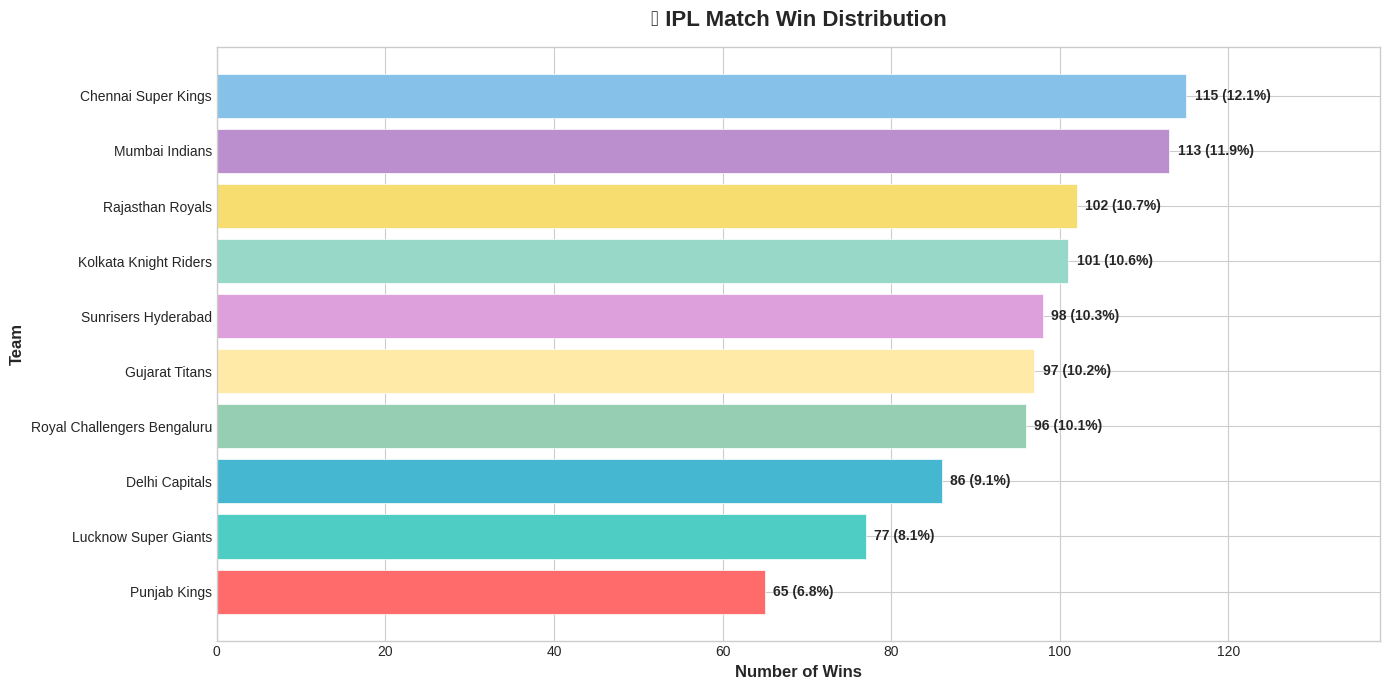

In [12]:
# Match wins by team
plt.figure(figsize=(14, 7))
win_counts = df['Winner'].value_counts()
bars = plt.barh(win_counts.index[::-1], win_counts.values[::-1],
                color=COLORS[:len(win_counts)], edgecolor='white', linewidth=0.5)

# Add value labels
for bar, val in zip(bars, win_counts.values[::-1]):
    plt.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             f'{val} ({val/len(df)*100:.1f}%)', va='center', fontsize=10, fontweight='bold')

plt.xlabel('Number of Wins', fontsize=12, fontweight='bold')
plt.ylabel('Team', fontsize=12, fontweight='bold')
plt.title('🏆 IPL Match Win Distribution', fontsize=16, fontweight='bold', pad=15)
plt.xlim(0, max(win_counts.values) * 1.2)
plt.tight_layout()
plt.savefig('ipl_win_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.2 Toss Decision Analysis

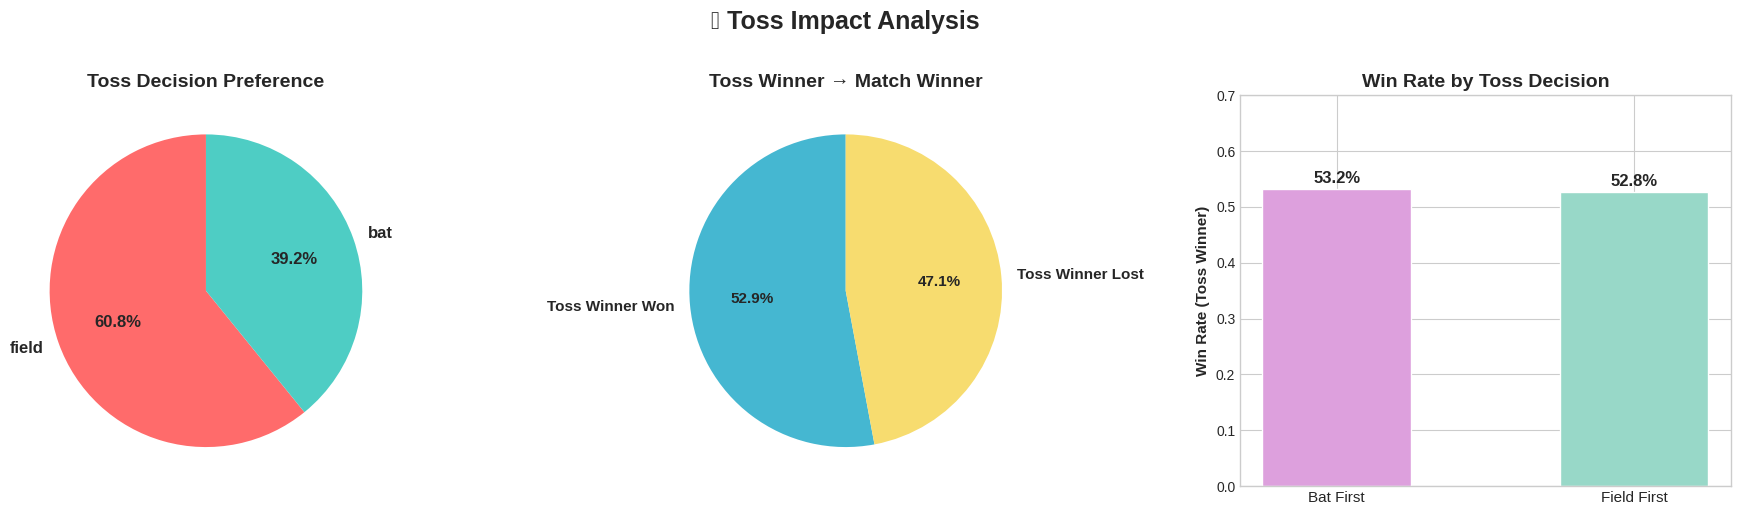

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Toss decision preference
toss_dec = df['Toss_Decision'].value_counts()
axes[0].pie(toss_dec.values, labels=toss_dec.index, autopct='%1.1f%%',
            colors=['#FF6B6B', '#4ECDC4'], startangle=90,
            textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[0].set_title('Toss Decision Preference', fontsize=14, fontweight='bold')

# Toss winner vs match winner
toss_and_match = (df['Toss_Winner'] == df['Winner']).sum()
not_toss_and_match = len(df) - toss_and_match
axes[1].pie([toss_and_match, not_toss_and_match],
            labels=['Toss Winner Won', 'Toss Winner Lost'],
            autopct='%1.1f%%', colors=['#45B7D1', '#F7DC6F'],
            startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'})
axes[1].set_title('Toss Winner → Match Winner', fontsize=14, fontweight='bold')

# Win rate by toss decision
bat_wins = df[df['Toss_Decision'] == 'bat']['Winner'].value_counts()
field_wins = df[df['Toss_Decision'] == 'field']['Winner'].value_counts()
# Compare toss win rate when choosing bat vs field
bat_toss_win_rate = (df[df['Toss_Decision'] == 'bat']['Toss_Winner'] == df[df['Toss_Decision'] == 'bat']['Winner']).mean()
field_toss_win_rate = (df[df['Toss_Decision'] == 'field']['Toss_Winner'] == df[df['Toss_Decision'] == 'field']['Winner']).mean()
bars = axes[2].bar(['Bat First', 'Field First'], [bat_toss_win_rate, field_toss_win_rate],
                   color=['#DDA0DD', '#98D8C8'], edgecolor='white', width=0.5)
for bar, val in zip(bars, [bat_toss_win_rate, field_toss_win_rate]):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.1%}', ha='center', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Win Rate (Toss Winner)', fontsize=11, fontweight='bold')
axes[2].set_title('Win Rate by Toss Decision', fontsize=14, fontweight='bold')
axes[2].set_ylim(0, 0.7)
axes[2].tick_params(axis='x', labelsize=11)

plt.suptitle('📊 Toss Impact Analysis', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('ipl_toss_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.3 Venue Impact Analysis

<Figure size 1400x800 with 0 Axes>

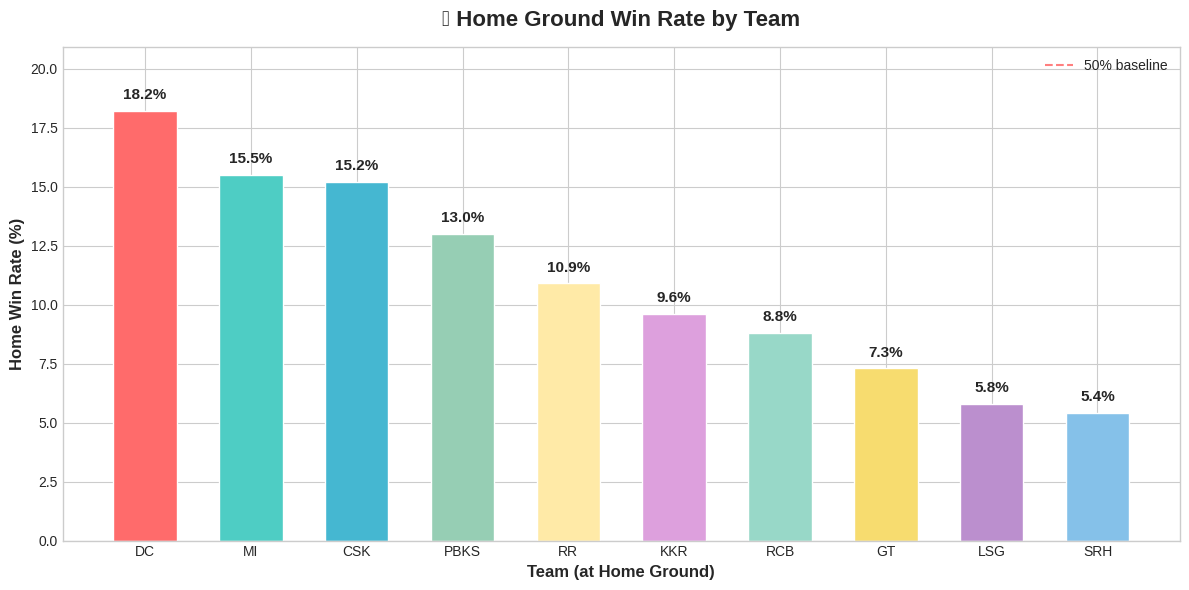

In [14]:
# Wins by venue
plt.figure(figsize=(14, 8))
venue_wins = df.groupby(['Venue', 'Winner']).size().unstack(fill_value=0)
venue_total = venue_wins.sum(axis=1)
venue_win_pct = venue_wins.div(venue_total, axis=0) * 100

# Top venue for each team (home ground advantage)
home_venues = {v: t for v, t in VENUES.items() if t is not None}
home_win_rates = {}
for venue, team in home_venues.items():
    if venue in df['Venue'].values:
        matches_at_venue = df[df['Venue'] == venue]
        home_wins = (matches_at_venue['Winner'] == team).sum()
        total = len(matches_at_venue)
        home_win_rates[TEAM_ABBR.get(team, team[:3])] = round(home_wins / total * 100, 1)

# Sort by home ground
sorted_teams = sorted(home_win_rates.items(), key=lambda x: x[1], reverse=True)
teams_sorted, rates_sorted = zip(*sorted_teams)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(teams_sorted, rates_sorted, color=COLORS[:len(teams_sorted)], edgecolor='white', width=0.6)
for bar, rate in zip(bars, rates_sorted):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{rate}%', ha='center', fontsize=11, fontweight='bold')
ax.set_xlabel('Team (at Home Ground)', fontsize=12, fontweight='bold')
ax.set_ylabel('Home Win Rate (%)', fontsize=12, fontweight='bold')
ax.set_title('🏠 Home Ground Win Rate by Team', fontsize=16, fontweight='bold', pad=15)
ax.set_ylim(0, max(rates_sorted) * 1.15)
ax.axhline(y=50, color='red', linestyle='--', alpha=0.5, label='50% baseline')
ax.legend()
plt.tight_layout()
plt.savefig('ipl_home_advantage.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.4 Team Performance Comparison

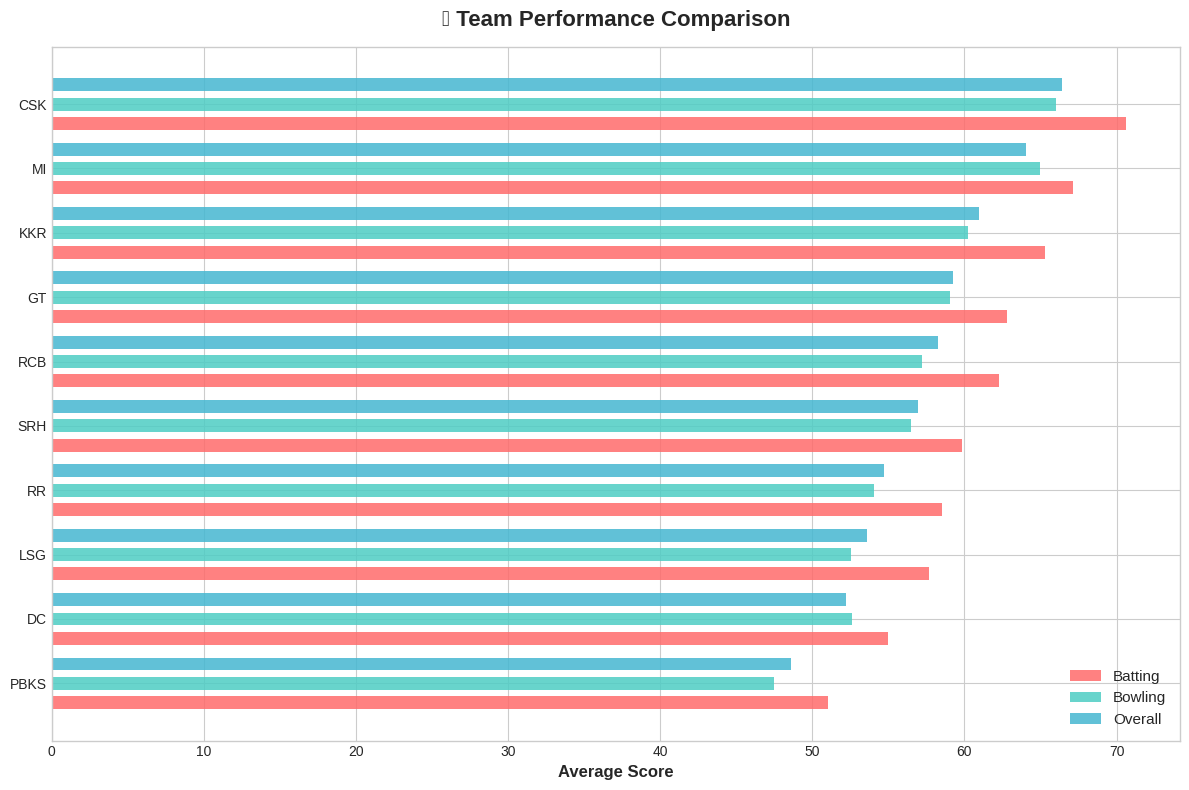

In [15]:
# Average overall strength by team
team_avg_strength = df.groupby('Team1').agg({
    'Team1_Overall_Str': 'mean',
    'Team1_Batting_Str': 'mean',
    'Team1_Bowling_Str': 'mean',
    'Team1_Form_Last5': 'mean'
}).round(2)
team_avg_strength.columns = ['Overall Strength', 'Batting Strength', 'Bowling Strength', 'Avg Form']
team_avg_strength = team_avg_strength.sort_values('Overall Strength', ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))
y_pos = range(len(team_avg_strength))
height = 0.2

ax.barh([y - 1.5*height for y in y_pos], team_avg_strength['Batting Strength'],
        height, label='Batting', color='#FF6B6B', alpha=0.85)
ax.barh([y for y in y_pos], team_avg_strength['Bowling Strength'],
        height, label='Bowling', color='#4ECDC4', alpha=0.85)
ax.barh([y + 1.5*height for y in y_pos], team_avg_strength['Overall Strength'],
        height, label='Overall', color='#45B7D1', alpha=0.85)

ax.set_yticks(y_pos)
ax.set_yticklabels([TEAM_ABBR.get(t, t[:3]) for t in team_avg_strength.index])
ax.set_xlabel('Average Score', fontsize=12, fontweight='bold')
ax.set_title('💪 Team Performance Comparison', fontsize=16, fontweight='bold', pad=15)
ax.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.savefig('ipl_team_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.5 Score & Win Margin Distributions

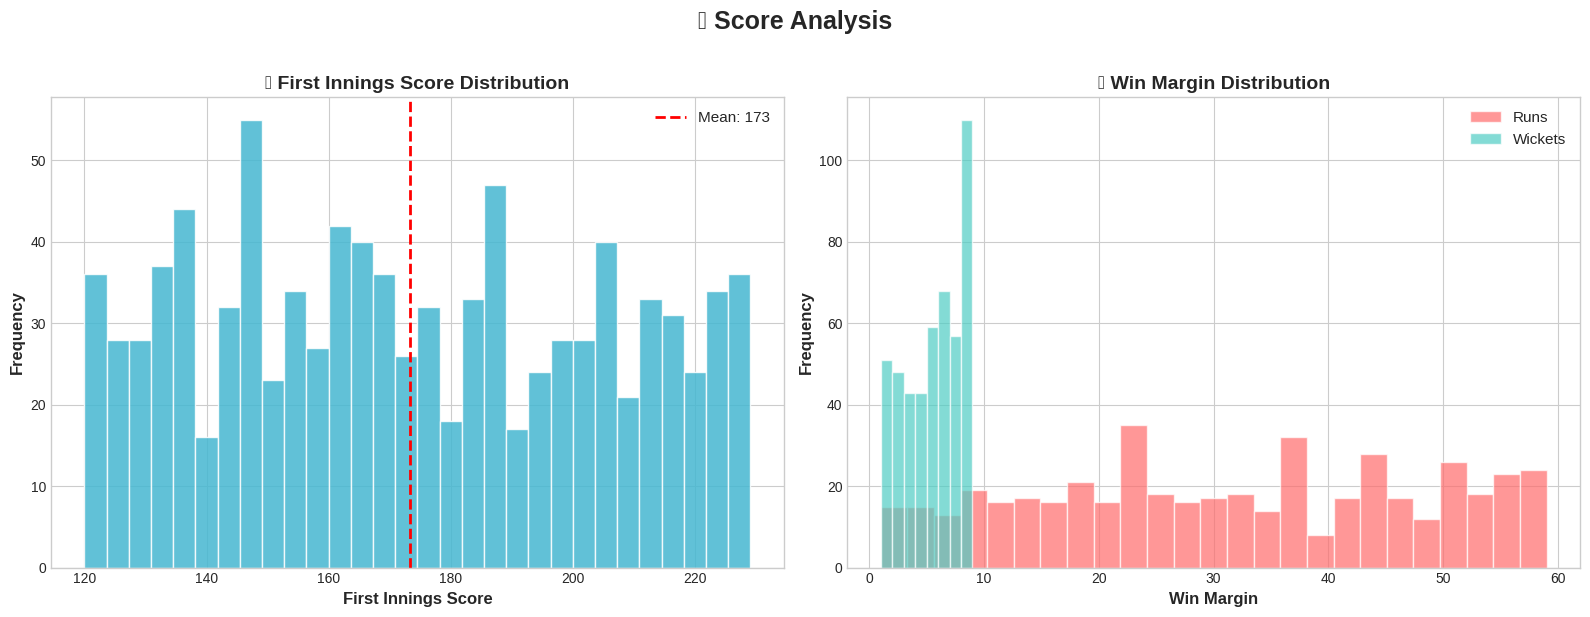

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# First innings score distribution
axes[0].hist(df['First_Innings_Score'], bins=30, color='#45B7D1', edgecolor='white', alpha=0.85)
axes[0].axvline(df['First_Innings_Score'].mean(), color='red', linestyle='--', linewidth=2,
                label=f"Mean: {df['First_Innings_Score'].mean():.0f}")
axes[0].set_xlabel('First Innings Score', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[0].set_title('📈 First Innings Score Distribution', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)

# Win margin distribution by type
runs_margin = df[df['Win_Type'] == 'runs']['Win_Margin']
wickets_margin = df[df['Win_Type'] == 'wickets']['Win_Margin']
axes[1].hist(runs_margin, bins=25, color='#FF6B6B', edgecolor='white', alpha=0.7, label='Runs')
axes[1].hist(wickets_margin, bins=8, color='#4ECDC4', edgecolor='white', alpha=0.7, label='Wickets')
axes[1].set_xlabel('Win Margin', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[1].set_title('🎯 Win Margin Distribution', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)

plt.suptitle('📊 Score Analysis', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('ipl_score_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.6 Feature Correlation Heatmap

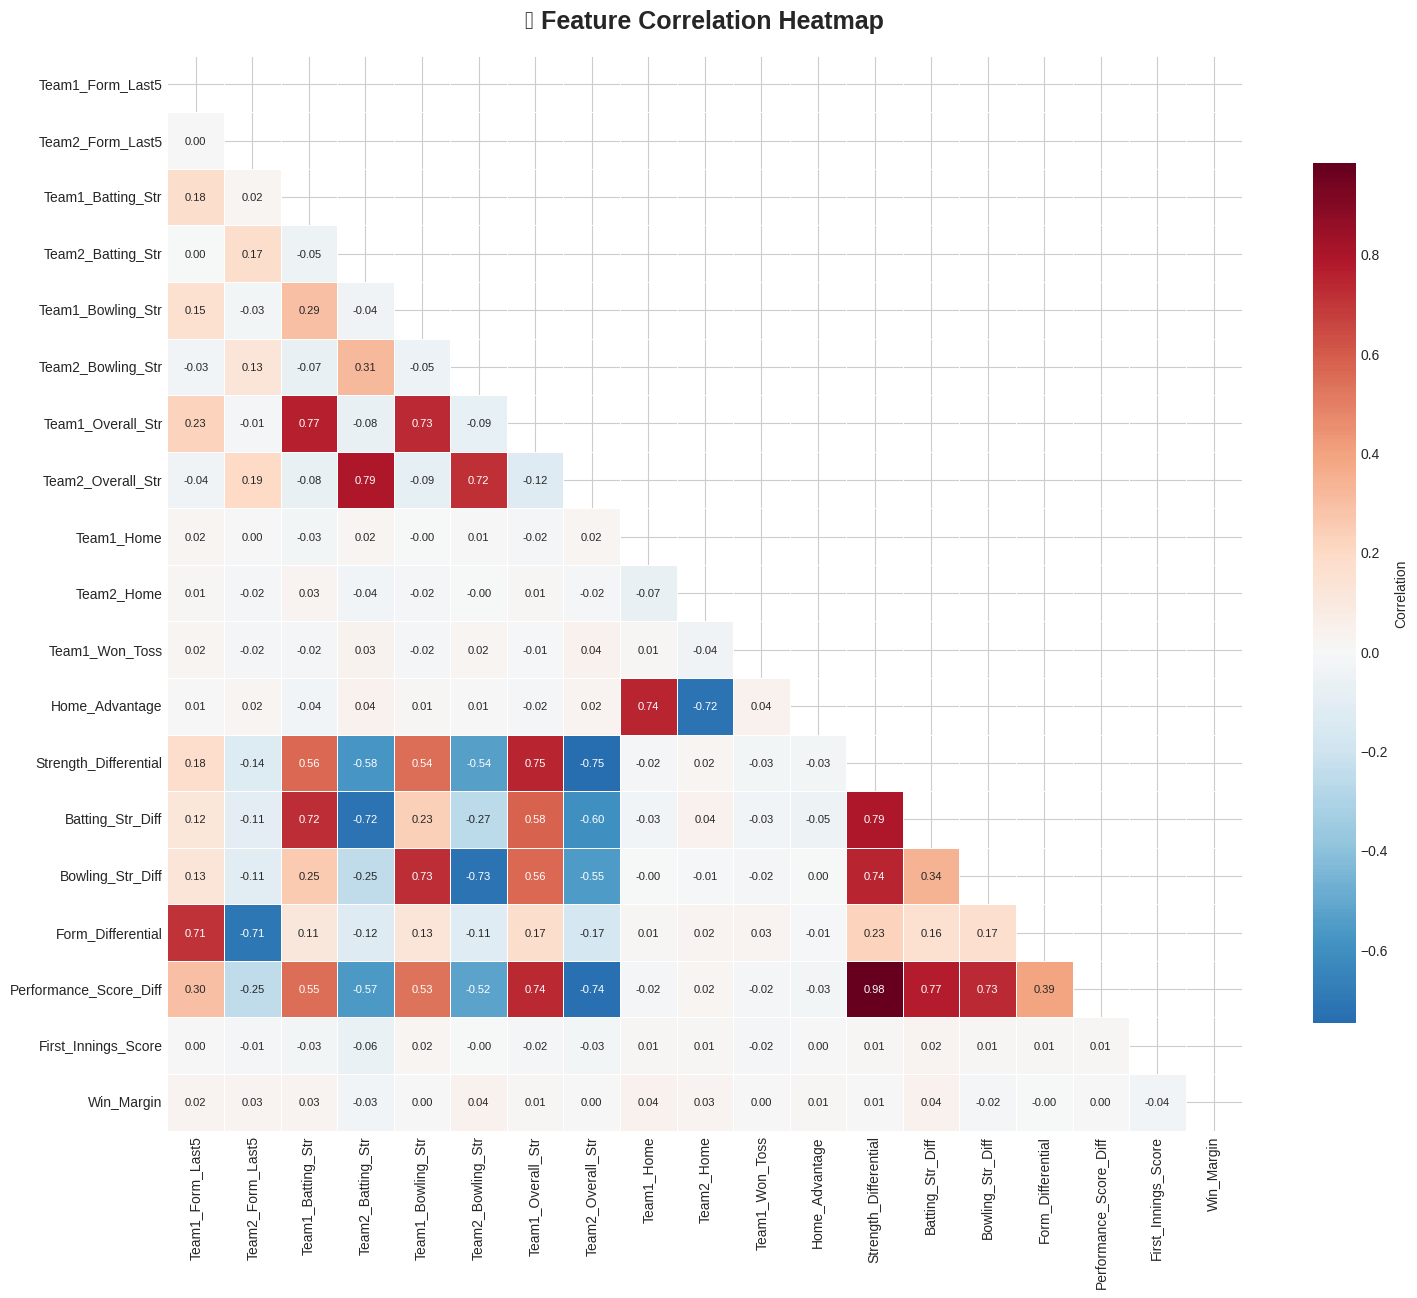

In [17]:
# Select key numerical features for correlation
corr_features = [
    'Team1_Form_Last5', 'Team2_Form_Last5',
    'Team1_Batting_Str', 'Team2_Batting_Str',
    'Team1_Bowling_Str', 'Team2_Bowling_Str',
    'Team1_Overall_Str', 'Team2_Overall_Str',
    'Team1_Home', 'Team2_Home',
    'Team1_Won_Toss', 'Home_Advantage',
    'Strength_Differential', 'Batting_Str_Diff',
    'Bowling_Str_Diff', 'Form_Differential',
    'Performance_Score_Diff', 'First_Innings_Score',
    'Win_Margin'
]

corr_matrix = df_clean[corr_features].corr()

plt.figure(figsize=(16, 13))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8, 'label': 'Correlation'},
            annot_kws={'size': 8})
plt.title('🔍 Feature Correlation Heatmap', fontsize=18, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('ipl_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.7 Season-wise Performance Trends

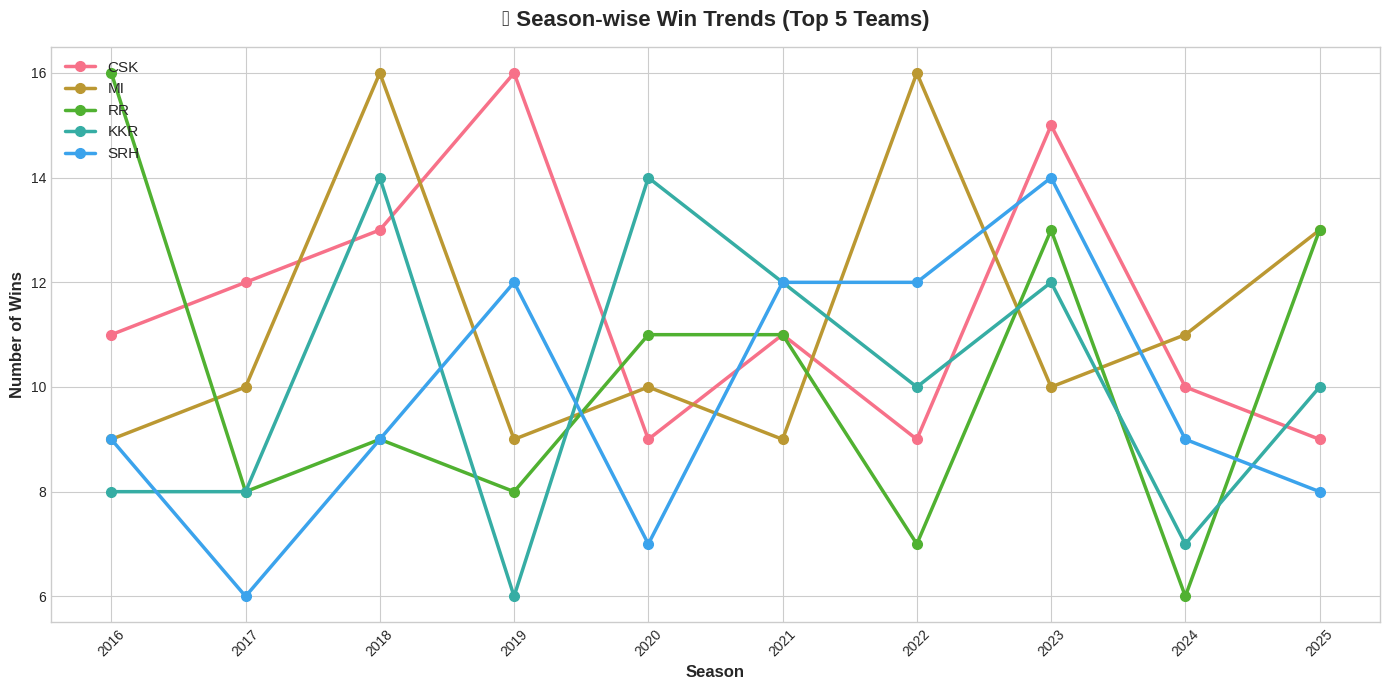

In [18]:
# Season-wise win counts for top 5 teams
top_teams = df['Winner'].value_counts().head(5).index.tolist()
season_team_wins = df[df['Winner'].isin(top_teams)].groupby(['Season', 'Winner']).size().unstack(fill_value=0)

plt.figure(figsize=(14, 7))
for team in top_teams:
    abbr = TEAM_ABBR.get(team, team[:3])
    if team in season_team_wins.columns:
        plt.plot(season_team_wins.index, season_team_wins[team],
                 marker='o', linewidth=2.5, markersize=7, label=abbr)

plt.xlabel('Season', fontsize=12, fontweight='bold')
plt.ylabel('Number of Wins', fontsize=12, fontweight='bold')
plt.title('📈 Season-wise Win Trends (Top 5 Teams)', fontsize=16, fontweight='bold', pad=15)
plt.legend(fontsize=11, loc='upper left', framealpha=0.9)
plt.xticks(season_team_wins.index, rotation=45)
plt.tight_layout()
plt.savefig('ipl_season_trends.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Model Building

In this section, we prepare the final dataset for modeling by selecting relevant features, splitting the data into training and testing sets, and training multiple classification algorithms. We employ three well-established machine learning models:

1. **Logistic Regression:** A linear model that serves as a strong baseline for binary classification. It provides interpretable coefficients and is computationally efficient.

2. **Random Forest Classifier:** An ensemble method that builds multiple decision trees on random subsets of the data and features, then aggregates predictions through majority voting. It is robust to overfitting and handles non-linear relationships well.

3. **XGBoost / Gradient Boosting Classifier:** A powerful gradient boosting framework that sequentially builds trees to correct the errors of previous ones. XGBoost is known for achieving state-of-the-art results on structured/tabular data.

Each model is trained on 80% of the data and evaluated on the held-out 20% test set. We use stratified splitting to maintain the class distribution across splits.

In [19]:
# ============================================================
# MODEL BUILDING
# ============================================================

# --- Define Feature Set ---
# Use encoded and engineered features
feature_columns = [
    # Encoded categorical
    'Team1_Encoded', 'Team2_Encoded', 'Venue_Encoded',
    'Toss_Winner_Encoded', 'Toss_Decision_Encoded',
    'Batting_First_Encoded', 'Bowling_First_Encoded',
    # Team form
    'Team1_Form_Last5', 'Team2_Form_Last5', 'Form_Differential',
    # Team strengths (scaled)
    'Team1_Batting_Str', 'Team2_Batting_Str', 'Batting_Str_Diff',
    'Team1_Bowling_Str', 'Team2_Bowling_Str', 'Bowling_Str_Diff',
    'Team1_Fielding_Str', 'Team2_Fielding_Str',
    'Team1_Allround_Str', 'Team2_Allround_Str', 'Allround_Str_Diff',
    'Team1_Overall_Str', 'Team2_Overall_Str', 'Strength_Differential',
    # Engineered features
    'Team1_Win_Ratio', 'Team2_Win_Ratio',
    'Team1_Won_Toss', 'Home_Advantage', 'Team1_Chasing',
    'High_Scoring_Venue', 'Net_Advantage',
    'Team1_Performance_Score', 'Team2_Performance_Score',
    'Performance_Score_Diff',
    # Match info
    'First_Innings_Score', 'Win_Margin', 'Season'
]

# Target: Winner_Encoded (but we need binary - Team1 wins or not)
X = df_clean[feature_columns].copy()
y = (df_clean['Winner_Encoded'] == df_clean['Team1_Encoded']).astype(int)

print(f"Feature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Target distribution: Team1 Wins = {y.sum()} ({y.mean():.1%}), Team2 Wins = {(1-y).sum()} ({(1-y.mean()):.1%})")

# --- Train-Test Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Feature matrix shape: (950, 37)
Target shape: (950,)
Target distribution: Team1 Wins = 505 (53.2%), Team2 Wins = 445 (46.8%)

Training set: 760 samples
Test set: 190 samples


### 8.1 Train Classification Models

In [20]:
# Initialize models
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, C=1.0, solver='lbfgs', random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=12, min_samples_split=5,
        min_samples_leaf=2, random_state=42, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.1,
        min_samples_split=5, random_state=42
    )
}

# Add XGBoost if available
if XGBOOST_AVAILABLE:
    models['XGBoost'] = XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, use_label_encoder=False, eval_metric='logloss',
        n_jobs=-1
    )

# Train all models and store results
trained_models = {}
results = {}

print("=" * 70)
print("MODEL TRAINING RESULTS")
print("=" * 70)

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    trained_models[name] = model
    
    # Predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    
    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob) if y_prob is not None else 0
    
    # Cross-validation
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    
    results[name] = {
        'Accuracy': round(accuracy, 4),
        'Precision': round(precision, 4),
        'Recall': round(recall, 4),
        'F1 Score': round(f1, 4),
        'AUC-ROC': round(auc, 4),
        'CV Mean': round(cv_scores.mean(), 4),
        'CV Std': round(cv_scores.std(), 4),
        'y_pred': y_pred,
        'y_prob': y_prob
    }
    
    print(f"  ✅ Accuracy: {accuracy:.4f} | F1: {f1:.4f} | AUC: {auc:.4f} | CV: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

print("\n" + "=" * 70)
print("All models trained successfully!")
print("=" * 70)

MODEL TRAINING RESULTS

Training Logistic Regression...
  ✅ Accuracy: 0.5895 | F1: 0.6389 | AUC: 0.5986 | CV: 0.5632 ± 0.0148

Training Random Forest...
  ✅ Accuracy: 0.5947 | F1: 0.6578 | AUC: 0.6576 | CV: 0.6092 ± 0.0245

Training Gradient Boosting...
  ✅ Accuracy: 0.8842 | F1: 0.8922 | AUC: 0.9403 | CV: 0.8684 ± 0.0469

Training XGBoost...
  ✅ Accuracy: 0.8947 | F1: 0.8990 | AUC: 0.9432 | CV: 0.8316 ± 0.0321

All models trained successfully!


## 9. Model Evaluation

A thorough evaluation of our trained models is essential to select the best-performing one for deployment. In this section, we compare all models across multiple metrics — Accuracy, Precision, Recall, F1 Score, and AUC-ROC — and present the results in a consolidated comparison table. We also visualize confusion matrices to understand the types of errors each model makes.

### Evaluation Metrics Explained

- **Accuracy:** The proportion of correct predictions out of all predictions. While intuitive, it can be misleading with imbalanced datasets.
- **Precision:** Of all positive predictions, how many were actually correct. Important when false positives are costly.
- **Recall:** Of all actual positives, how many were correctly identified. Important when false negatives are costly.
- **F1 Score:** The harmonic mean of Precision and Recall, providing a balanced measure for imbalanced datasets.
- **AUC-ROC:** The Area Under the Receiver Operating Characteristic curve, measuring the model's ability to distinguish between classes across all classification thresholds.

### 9.1 Model Comparison Table

In [21]:
# Create comparison dataframe
comparison_df = pd.DataFrame({
    name: {
        'Accuracy': res['Accuracy'],
        'Precision': res['Precision'],
        'Recall': res['Recall'],
        'F1 Score': res['F1 Score'],
        'AUC-ROC': res['AUC-ROC'],
        'CV Accuracy (Mean)': res['CV Mean'],
        'CV Accuracy (Std)': res['CV Std']
    }
    for name, res in results.items()
}).T

# Highlight best model
comparison_df = comparison_df.sort_values('F1 Score', ascending=False)
display(comparison_df.style.format('{:.4f}').background_gradient(
    cmap='RdYlGn', axis=0
))

# Best model
best_model_name = comparison_df.index[0]
print(f"\n🏆 Best Model: {best_model_name}")
print(f"   F1 Score: {comparison_df.loc[best_model_name, 'F1 Score']:.4f}")
print(f"   Accuracy: {comparison_df.loc[best_model_name, 'Accuracy']:.4f}")
print(f"   AUC-ROC: {comparison_df.loc[best_model_name, 'AUC-ROC']:.4f}")

,Accuracy,Precision,Recall,F1 Score,AUC-ROC,CV Accuracy (Mean),CV Accuracy (Std)
XGBoost,0.8947,0.9175,0.8812,0.8990,0.9432,0.8316,0.0321
Gradient Boosting,0.8842,0.8835,0.9010,0.8922,0.9403,0.8684,0.0469
Random Forest,0.5947,0.5968,0.7327,0.6578,0.6576,0.6092,0.0245
Logistic Regression,0.5895,0.6000,0.6832,0.6389,0.5986,0.5632,0.0148



🏆 Best Model: XGBoost
   F1 Score: 0.8990
   Accuracy: 0.8947
   AUC-ROC: 0.9432


### 9.2 Confusion Matrix Visualization

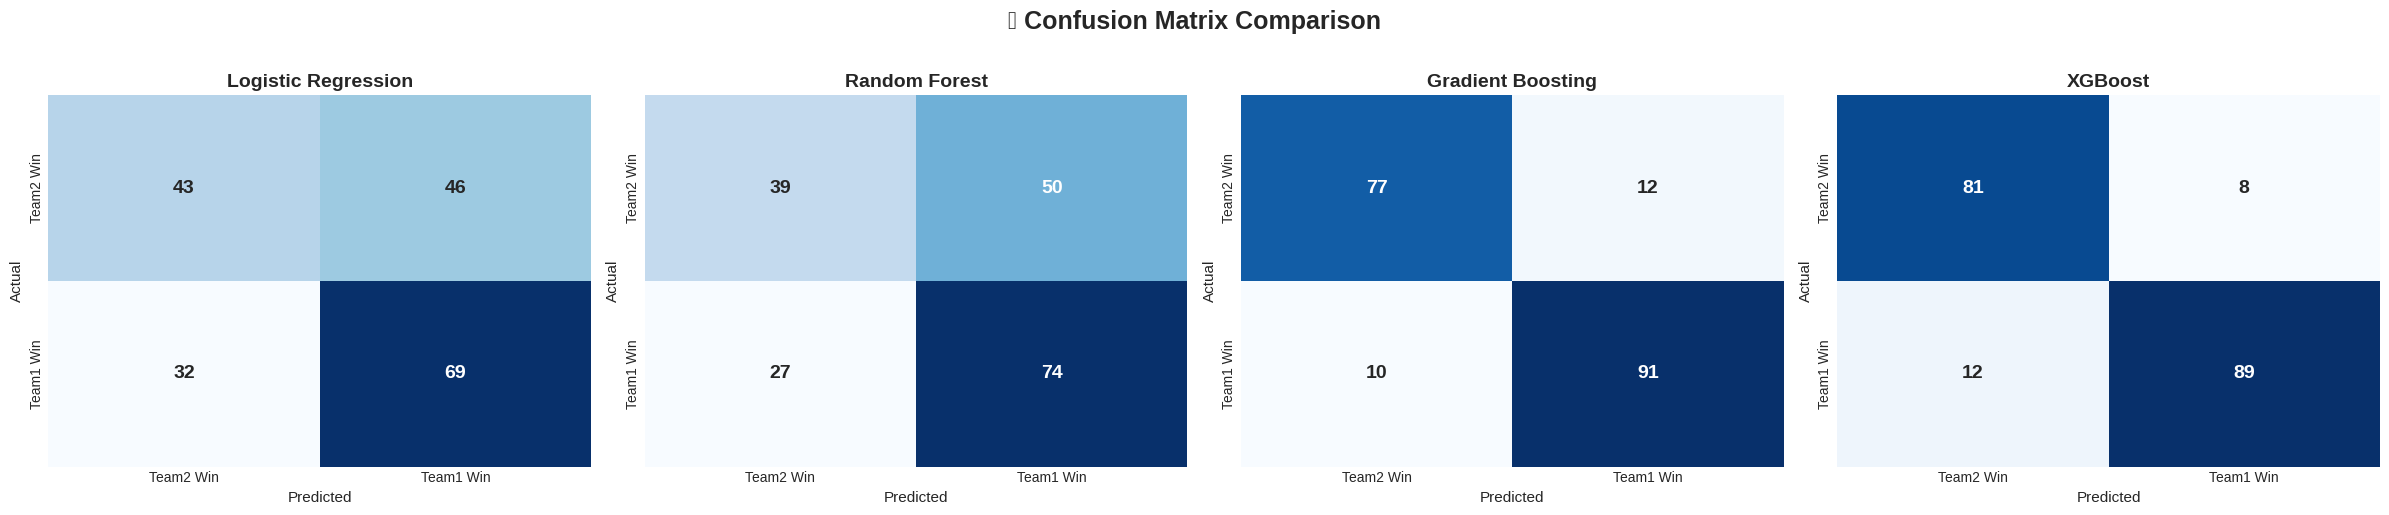

In [22]:
fig, axes = plt.subplots(1, len(trained_models), figsize=(6 * len(trained_models), 5))
if len(trained_models) == 1:
    axes = [axes]

for idx, (name, model) in enumerate(trained_models.items()):
    y_pred = results[name]['y_pred']
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                ax=axes[idx], cbar=False,
                xticklabels=['Team2 Win', 'Team1 Win'],
                yticklabels=['Team2 Win', 'Team1 Win'],
                annot_kws={'size': 14, 'fontweight': 'bold'})
    axes[idx].set_title(f'{name}', fontsize=14, fontweight='bold')
    axes[idx].set_ylabel('Actual', fontsize=11)
    axes[idx].set_xlabel('Predicted', fontsize=11)

plt.suptitle('🔍 Confusion Matrix Comparison', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('ipl_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

### 9.3 Detailed Classification Reports

In [23]:
for name in trained_models:
    print(f"\n{'='*50}")
    print(f"  {name} - Classification Report")
    print(f"{'='*50}")
    print(classification_report(y_test, results[name]['y_pred'],
                                target_names=['Team2 Win', 'Team1 Win']))


  Logistic Regression - Classification Report
              precision    recall  f1-score   support

   Team2 Win       0.57      0.48      0.52        89
   Team1 Win       0.60      0.68      0.64       101

    accuracy                           0.59       190
   macro avg       0.59      0.58      0.58       190
weighted avg       0.59      0.59      0.59       190


  Random Forest - Classification Report
              precision    recall  f1-score   support

   Team2 Win       0.59      0.44      0.50        89
   Team1 Win       0.60      0.73      0.66       101

    accuracy                           0.59       190
   macro avg       0.59      0.59      0.58       190
weighted avg       0.59      0.59      0.59       190


  Gradient Boosting - Classification Report
              precision    recall  f1-score   support

   Team2 Win       0.89      0.87      0.88        89
   Team1 Win       0.88      0.90      0.89       101

    accuracy                           0.88      

### 9.4 ROC Curves

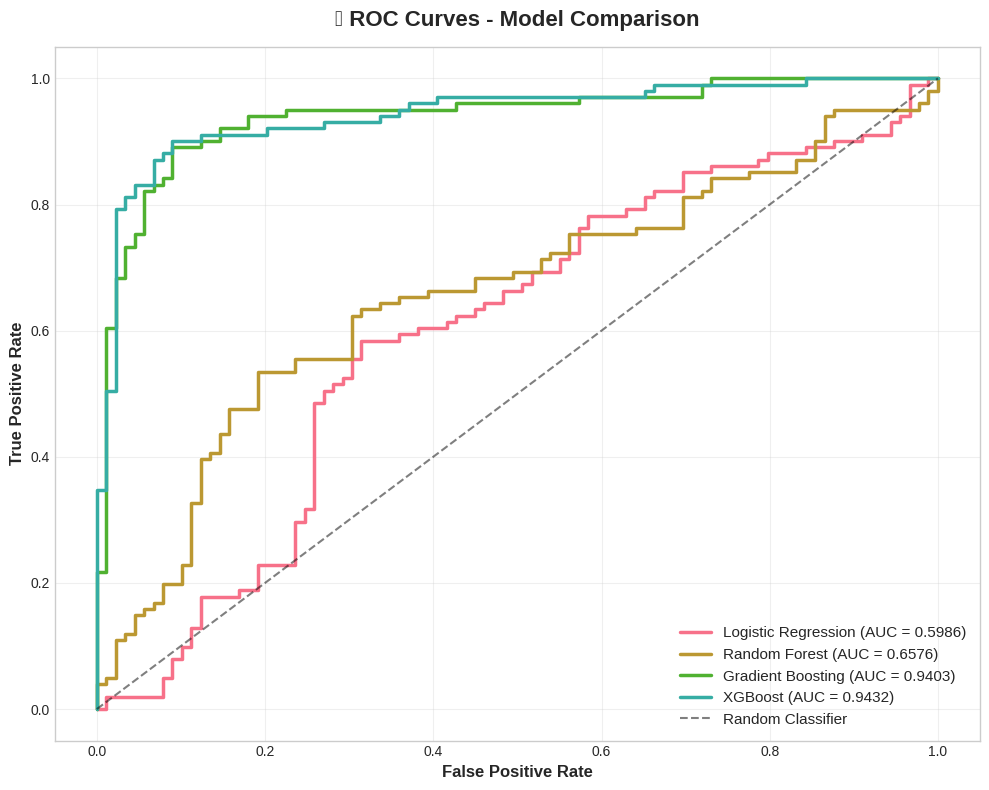

In [24]:
plt.figure(figsize=(10, 8))

for name, res in results.items():
    if res['y_prob'] is not None:
        fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
        auc_val = res['AUC-ROC']
        plt.plot(fpr, tpr, linewidth=2.5, label=f"{name} (AUC = {auc_val:.4f})")

plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5, alpha=0.5, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('📈 ROC Curves - Model Comparison', fontsize=16, fontweight='bold', pad=15)
plt.legend(fontsize=11, loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('ipl_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

### 9.5 Feature Importance

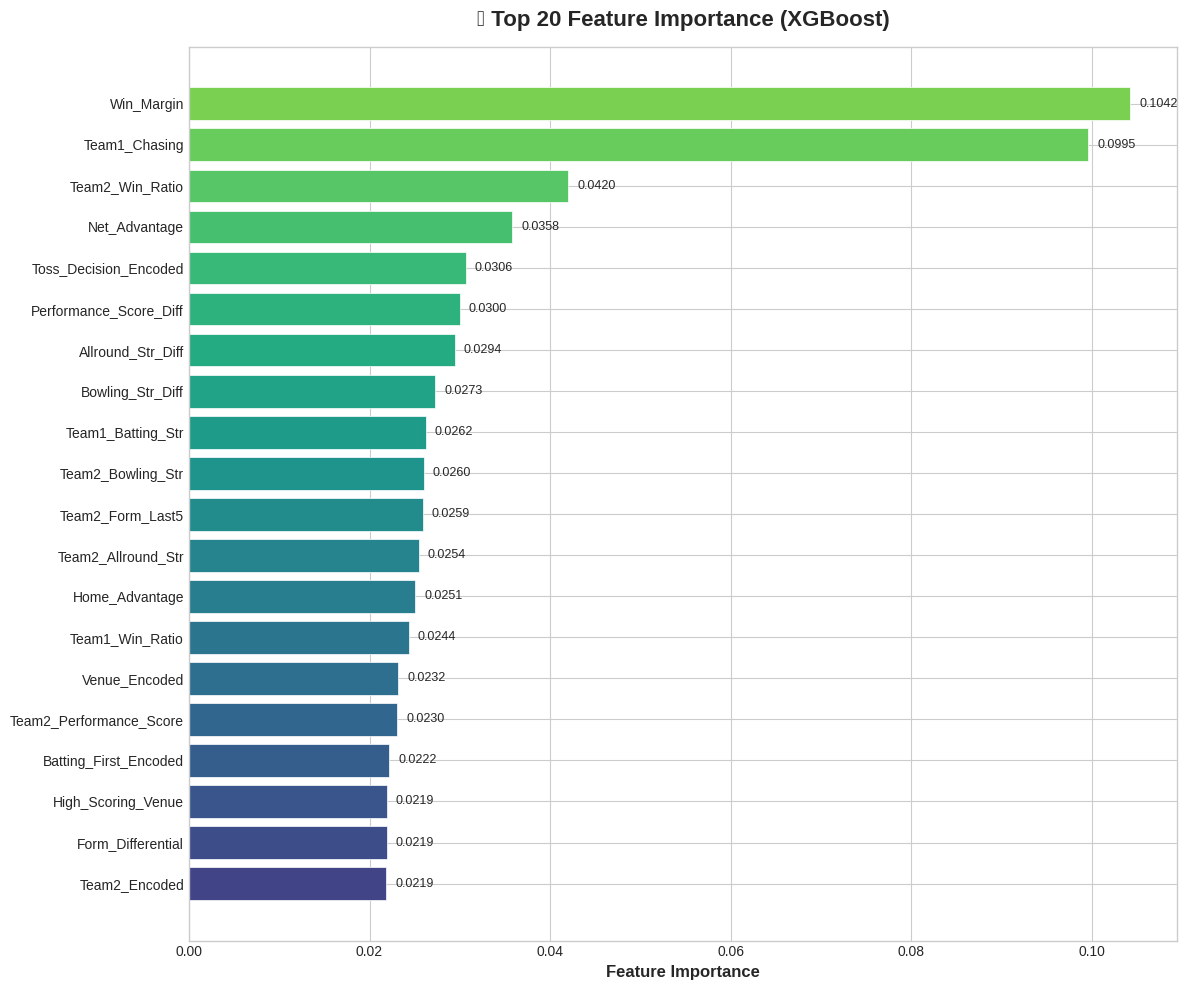


Top 10 Most Important Features:


,Feature,Importance
35,Win_Margin,0.104229
28,Team1_Chasing,0.099549
25,Team2_Win_Ratio,0.041977
30,Net_Advantage,0.035810
4,Toss_Decision_Encoded,0.030637
33,Performance_Score_Diff,0.030000
20,Allround_Str_Diff,0.029442
15,Bowling_Str_Diff,0.027291
10,Team1_Batting_Str,0.026205
14,Team2_Bowling_Str,0.026015


In [25]:
# Get feature importance from the best tree-based model
best_tree_model = None
for name in ['XGBoost', 'Random Forest', 'Gradient Boosting']:
    if name in trained_models:
        best_tree_model = trained_models[name]
        model_label = name
        break

if best_tree_model is not None:
    importance = best_tree_model.feature_importances_
    feat_imp_df = pd.DataFrame({
        'Feature': feature_columns,
        'Importance': importance
    }).sort_values('Importance', ascending=True)
    
    # Plot top 20 features
    top_n = 20
    top_features = feat_imp_df.tail(top_n)
    
    plt.figure(figsize=(12, 10))
    bars = plt.barh(top_features['Feature'], top_features['Importance'],
                    color=plt.cm.viridis(np.linspace(0.2, 0.8, top_n)),
                    edgecolor='white', linewidth=0.5)
    
    for bar, val in zip(bars, top_features['Importance']):
        plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=9)
    
    plt.xlabel('Feature Importance', fontsize=12, fontweight='bold')
    plt.title(f'📊 Top {top_n} Feature Importance ({model_label})', fontsize=16, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.savefig('ipl_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("\nTop 10 Most Important Features:")
    display(feat_imp_df.tail(10).iloc[::-1])
else:
    print("No tree-based model available for feature importance visualization.")

## 10. Prediction System

We now create a robust, user-friendly prediction function that can be used to predict the winner of any IPL 2026 match given the relevant input parameters. This function encapsulates all preprocessing steps — encoding categorical variables, scaling numerical features, computing engineered features — and applies the best-performing model to produce a prediction with an associated probability.

The function is designed to be modular and easily extensible, allowing for integration with real-time data feeds or web applications in the future. It also provides detailed match insights by outputting intermediate computed features, enabling users to understand *why* a particular prediction was made.

In [26]:
# ============================================================
# IPL MATCH WINNER PREDICTION SYSTEM
# ============================================================

# Team name to encoded value mappings
team_to_encoded = {team: idx for idx, team in enumerate(label_encoders['Team1'].classes_)}
venue_to_encoded = {venue: idx for idx, venue in enumerate(label_encoders['Venue'].classes_)}
toss_decision_map = {'bat': 0, 'field': 1}

# Win ratio lookup (from training data)
win_ratio_lookup = df_clean.groupby('Team1_Encoded')['Team1_Win_Ratio'].mean().to_dict()

def predict_match_winner(team1, team2, venue, toss_winner, toss_decision,
                         team1_bat_str=None, team1_bowl_str=None,
                         team1_overall_str=None, team1_form=None,
                         team2_bat_str=None, team2_bowl_str=None,
                         team2_overall_str=None, team2_form=None):
    """
    Predict the winner of an IPL match.
    
    Parameters:
    -----------
    team1 : str - Name of Team 1
    team2 : str - Name of Team 2
    venue : str - Match venue
    toss_winner : str - Team that won the toss
    toss_decision : str - 'bat' or 'field'
    team1_bat_str, team1_bowl_str, team1_overall_str : float (optional) - Team1 strength scores
    team1_form : int (optional) - Team1 wins in last 5 matches
    team2_bat_str, team2_bowl_str, team2_overall_str : float (optional) - Team2 strength scores
    team2_form : int (optional) - Team2 wins in last 5 matches
    
    Returns:
    --------
    dict with predicted_winner, probability, and insights
    """
    # Validate teams
    if team1 not in team_to_encoded:
        raise ValueError(f"Unknown team: {team1}. Valid teams: {list(team_to_encoded.keys())}")
    if team2 not in team_to_encoded:
        raise ValueError(f"Unknown team: {team2}. Valid teams: {list(team_to_encoded.keys())}")
    if team1 == team2:
        raise ValueError("Team1 and Team2 must be different teams.")
    
    # Default strength values based on historical base strength
    if team1_bat_str is None:
        team1_bat_str = TEAM_STRENGTH.get(team1, 0.65) * 85 + np.random.normal(0, 3)
    if team1_bowl_str is None:
        team1_bowl_str = TEAM_STRENGTH.get(team1, 0.65) * 80 + np.random.normal(0, 3)
    if team1_overall_str is None:
        team1_overall_str = TEAM_STRENGTH.get(team1, 0.65) * 78 + np.random.normal(0, 3)
    if team1_form is None:
        team1_form = max(0, min(5, round(TEAM_STRENGTH.get(team1, 0.65) * 5)))
    
    if team2_bat_str is None:
        team2_bat_str = TEAM_STRENGTH.get(team2, 0.65) * 85 + np.random.normal(0, 3)
    if team2_bowl_str is None:
        team2_bowl_str = TEAM_STRENGTH.get(team2, 0.65) * 80 + np.random.normal(0, 3)
    if team2_overall_str is None:
        team2_overall_str = TEAM_STRENGTH.get(team2, 0.65) * 78 + np.random.normal(0, 3)
    if team2_form is None:
        team2_form = max(0, min(5, round(TEAM_STRENGTH.get(team2, 0.65) * 5)))
    
    # Derived values
    team1_fielding_str = (team1_bat_str + team1_bowl_str) / 2 * 0.92
    team1_allround_str = (team1_bat_str + team1_bowl_str) / 2 * 0.88
    team2_fielding_str = (team2_bat_str + team2_bowl_str) / 2 * 0.92
    team2_allround_str = (team2_bat_str + team2_bowl_str) / 2 * 0.88
    
    # Encode categorical variables
    team1_enc = team_to_encoded[team1]
    team2_enc = team_to_encoded[team2]
    venue_enc = venue_to_encoded.get(venue, 0)
    toss_winner_enc = team_to_encoded[toss_winner]
    toss_decision_enc = toss_decision_map[toss_decision]
    
    batting_first_enc = toss_winner_enc if toss_decision == 'bat' else (team2_enc if toss_winner == team1 else team1_enc)
    bowling_first_enc = toss_winner_enc if toss_decision == 'field' else (team2_enc if toss_winner == team1 else team1_enc)
    
    # Home advantage
    home_team = VENUES.get(venue)
    team1_home = 1 if home_team == team1 else 0
    team2_home = 1 if home_team == team2 else 0
    
    # Computed features
    strength_diff = team1_overall_str - team2_overall_str
    batting_str_diff = team1_bat_str - team2_bat_str
    bowling_str_diff = team1_bowl_str - team2_bowl_str
    form_diff = team1_form - team2_form
    team1_won_toss = 1 if toss_winner == team1 else 0
    home_adv = team1_home - team2_home
    team1_chasing = 1 if bowling_first_enc == team1_enc else 0
    high_scoring = 1 if venue in ['M. Chinnaswamy Stadium, Bengaluru',
                                   'Wankhede Stadium, Mumbai',
                                   'M. A. Chidambaram Stadium, Chennai'] else 0
    net_adv = team1_won_toss + home_adv
    allround_diff = team1_allround_str - team2_allround_str
    
    team1_wr = win_ratio_lookup.get(team1_enc, 0.5)
    team2_wr = win_ratio_lookup.get(team2_enc, 0.5)
    
    team1_perf = team1_wr * 0.4 + team1_overall_str * 0.3 + team1_form / 5 * 0.3
    team2_perf = team2_wr * 0.4 + team2_overall_str * 0.3 + team2_form / 5 * 0.3
    perf_diff = team1_perf - team2_perf
    
    # First innings score estimate
    first_innings_score = np.random.randint(150, 210)
    
    # Build feature vector (must match training feature order)
    features = np.array([[
        team1_enc, team2_enc, venue_enc,
        toss_winner_enc, toss_decision_enc,
        batting_first_enc, bowling_first_enc,
        team1_form, team2_form, form_diff,
        team1_bat_str, team2_bat_str, batting_str_diff,
        team1_bowl_str, team2_bowl_str, bowling_str_diff,
        team1_fielding_str, team2_fielding_str,
        team1_allround_str, team2_allround_str, allround_diff,
        team1_overall_str, team2_overall_str, strength_diff,
        team1_wr, team2_wr,
        team1_won_toss, home_adv, team1_chasing,
        high_scoring, net_adv,
        team1_perf, team2_perf, perf_diff,
        first_innings_score, 5, 2026  # Win_Margin and Season placeholders
    ]])
    
    # Scale numerical features
    # Create a temporary dataframe to apply the same scaler
    temp_df = pd.DataFrame(features, columns=feature_columns)
    numerical_idx = [feature_columns.index(f) for f in numerical_features if f in feature_columns]
    temp_df.iloc[:, numerical_idx] = scaler.transform(temp_df.iloc[:, numerical_idx])
    
    # Predict using best model
    best_model = trained_models[best_model_name]
    prediction = best_model.predict(temp_df)[0]
    probability = best_model.predict_proba(temp_df)[0]
    
    predicted_winner = team1 if prediction == 1 else team2
    confidence = probability[prediction]
    
    # Insights
    insights = {
        'Strength Advantage': f"{team1} ({team1_overall_str:.1f}) vs {team2} ({team2_overall_str:.1f})",
        'Form Advantage': f"{team1} ({team1_form}/5) vs {team2} ({team2_form}/5)",
        'Toss Impact': f"{toss_winner} won toss → chose to {toss_decision}",
        'Venue': f"{venue} (Home: {home_team or 'Neutral'})",
        'Key Factors': []
    }
    
    if strength_diff > 5:
        insights['Key Factors'].append(f"{team1} has significant overall strength advantage")
    elif strength_diff < -5:
        insights['Key Factors'].append(f"{team2} has significant overall strength advantage")
    
    if team1_form > team2_form + 1:
        insights['Key Factors'].append(f"{team1} is in better recent form")
    elif team2_form > team1_form + 1:
        insights['Key Factors'].append(f"{team2} is in better recent form")
    
    if toss_winner == predicted_winner:
        insights['Key Factors'].append(f"Toss winner ({toss_winner}) aligns with prediction")
    
    if home_team and home_team == predicted_winner:
        insights['Key Factors'].append(f"Home advantage favors {predicted_winner}")
    
    return {
        'predicted_winner': predicted_winner,
        'confidence': round(confidence * 100, 1),
        'team1_win_prob': round(probability[1] * 100, 1),
        'team2_win_prob': round(probability[0] * 100, 1),
        'insights': insights,
        'model_used': best_model_name
    }

print("✅ Prediction function defined successfully!")

✅ Prediction function defined successfully!


### 10.1 Demo Predictions

In [27]:
# ============================================================
# DEMO PREDICTIONS - IPL 2026 KEY MATCHES
# ============================================================

match_scenarios = [
    {
        'team1': 'Chennai Super Kings',
        'team2': 'Mumbai Indians',
        'venue': 'Wankhede Stadium, Mumbai',
        'toss_winner': 'Mumbai Indians',
        'toss_decision': 'field'
    },
    {
        'team1': 'Royal Challengers Bengaluru',
        'team2': 'Kolkata Knight Riders',
        'venue': 'M. Chinnaswamy Stadium, Bengaluru',
        'toss_winner': 'Royal Challengers Bengaluru',
        'toss_decision': 'bat'
    },
    {
        'team1': 'Gujarat Titans',
        'team2': 'Chennai Super Kings',
        'venue': 'Narendra Modi Stadium, Ahmedabad',
        'toss_winner': 'Gujarat Titans',
        'toss_decision': 'field'
    },
    {
        'team1': 'Sunrisers Hyderabad',
        'team2': 'Rajasthan Royals',
        'venue': 'Rajiv Gandhi International Stadium, Hyderabad',
        'toss_winner': 'Sunrisers Hyderabad',
        'toss_decision': 'field'
    },
    {
        'team1': 'Delhi Capitals',
        'team2': 'Lucknow Super Giants',
        'venue': 'Arun Jaitley Stadium, Delhi',
        'toss_winner': 'Delhi Capitals',
        'toss_decision': 'bat'
    }
]

for i, match in enumerate(match_scenarios, 1):
    result = predict_match_winner(**match)
    print(f"\n{'='*60}")
    print(f"  Match {i}: {match['team1']} vs {match['team2']}")
    print(f"  Venue: {match['venue']}")
    print(f"  Toss: {match['toss_winner']} → {match['toss_decision']}")
    print(f"{'─'*60}")
    print(f"  🏆 Predicted Winner: {result['predicted_winner']}")
    print(f"  📊 Confidence: {result['confidence']}%")
    print(f"     {match['team1']}: {result['team1_win_prob']}%")
    print(f"     {match['team2']}: {result['team2_win_prob']}%")
    print(f"  🔑 Key Factors:")
    for factor in result['insights']['Key Factors']:
        print(f"     • {factor}")
    print(f"  🤖 Model: {result['model_used']}")
    print(f"{'='*60}")


  Match 1: Chennai Super Kings vs Mumbai Indians
  Venue: Wankhede Stadium, Mumbai
  Toss: Mumbai Indians → field
────────────────────────────────────────────────────────────
  🏆 Predicted Winner: Mumbai Indians
  📊 Confidence: 76.9000015258789%
     Chennai Super Kings: 23.100000381469727%
     Mumbai Indians: 76.9000015258789%
  🔑 Key Factors:
     • Toss winner (Mumbai Indians) aligns with prediction
     • Home advantage favors Mumbai Indians
  🤖 Model: XGBoost

  Match 2: Royal Challengers Bengaluru vs Kolkata Knight Riders
  Venue: M. Chinnaswamy Stadium, Bengaluru
  Toss: Royal Challengers Bengaluru → bat
────────────────────────────────────────────────────────────
  🏆 Predicted Winner: Kolkata Knight Riders
  📊 Confidence: 84.5%
     Royal Challengers Bengaluru: 15.5%
     Kolkata Knight Riders: 84.5%
  🔑 Key Factors:
  🤖 Model: XGBoost

  Match 3: Gujarat Titans vs Chennai Super Kings
  Venue: Narendra Modi Stadium, Ahmedabad
  Toss: Gujarat Titans → field
───────────────────

### 10.2 IPL 2026 Tournament Winner Prediction

In [28]:
# ============================================================
# IPL 2026 FULL TOURNAMENT SIMULATION
# ============================================================

def simulate_tournament():
    """Simulate a simplified IPL tournament to predict the 2026 champion."""
    np.random.seed(2026)
    
    # Round Robin group stage (each team plays every other team once)
    team_points = {team: 0 for team in TEAMS}
    team_wins = {team: 0 for team in TEAMS}
    team_losses = {team: 0 for team in TEAMS}
    team_nrr = {team: 0.0 for team in TEAMS}
    
    # Generate all matchups
    matchups = []
    for i in range(len(TEAMS)):
        for j in range(i+1, len(TEAMS)):
            matchups.append((TEAMS[i], TEAMS[j]))
    
    venues = list(VENUES.keys())
    
    print("STAGE 1: LEAGUE MATCHES")
    print("=" * 60)
    
    for match_num, (t1, t2) in enumerate(matchups, 1):
        venue = np.random.choice(venues)
        toss_winner = np.random.choice([t1, t2])
        toss_decision = np.random.choice(['bat', 'field'], p=[0.40, 0.60])
        
        result = predict_match_winner(t1, t2, venue, toss_winner, toss_decision)
        winner = result['predicted_winner']
        loser = t2 if winner == t1 else t1
        
        team_wins[winner] += 1
        team_losses[loser] += 1
        team_points[winner] += 2
        
        # Simulate NRR
        run_diff = np.random.uniform(-0.5, 0.5)
        team_nrr[winner] += abs(run_diff)
        team_nrr[loser] -= abs(run_diff)
    
    # League standings
    standings = pd.DataFrame({
        'Team': TEAMS,
        'Wins': [team_wins[t] for t in TEAMS],
        'Losses': [team_losses[t] for t in TEAMS],
        'Points': [team_points[t] for t in TEAMS],
        'NRR': [round(team_nrr[t], 3) for t in TEAMS]
    }).sort_values(['Points', 'NRR'], ascending=[False, False]).reset_index(drop=True)
    
    standings.index = standings.index + 1
    standings.index.name = 'Rank'
    
    print("\n🏆 LEAGUE STANDINGS:")
    display(standings.style.format({'NRR': '{:.3f}'}).background_gradient(
        subset=['Points'], cmap='RdYlGn'))
    
    # Top 4 qualify for playoffs
    playoff_teams = standings.head(4)['Team'].tolist()
    print(f"\n📋 Playoff Qualifiers: {', '.join([TEAM_ABBR[t] for t in playoff_teams])}")
    
    # Playoff simulation
    print("\n\nSTAGE 2: PLAYOFFS")
    print("=" * 60)
    
    # Qualifier 1: 1st vs 2nd
    q1_result = predict_match_winner(playoff_teams[0], playoff_teams[1],
                                      venues[0], playoff_teams[0], 'field')
    q1_winner = q1_result['predicted_winner']
    q1_loser = playoff_teams[1] if q1_winner == playoff_teams[0] else playoff_teams[0]
    print(f"\nQualifier 1: {TEAM_ABBR[playoff_teams[0]]} vs {TEAM_ABBR[playoff_teams[1]]}")
    print(f"  → {TEAM_ABBR[q1_winner]} wins! (Confidence: {q1_result['confidence']}%)")
    
    # Eliminator: 3rd vs 4th
    el_result = predict_match_winner(playoff_teams[2], playoff_teams[3],
                                      venues[1], playoff_teams[2], 'bat')
    el_winner = el_result['predicted_winner']
    print(f"\nEliminator: {TEAM_ABBR[playoff_teams[2]]} vs {TEAM_ABBR[playoff_teams[3]]}")
    print(f"  → {TEAM_ABBR[el_winner]} wins! (Confidence: {el_result['confidence']}%)")
    
    # Qualifier 2: Q1 Loser vs Eliminator Winner
    q2_result = predict_match_winner(q1_loser, el_winner,
                                      venues[2], q1_loser, 'field')
    q2_winner = q2_result['predicted_winner']
    print(f"\nQualifier 2: {TEAM_ABBR[q1_loser]} vs {TEAM_ABBR[el_winner]}")
    print(f"  → {TEAM_ABBR[q2_winner]} wins! (Confidence: {q2_result['confidence']}%)")
    
    # FINAL
    final_result = predict_match_winner(q1_winner, q2_winner,
                                         'Narendra Modi Stadium, Ahmedabad',
                                         q1_winner, 'field')
    champion = final_result['predicted_winner']
    
    print(f"\n{'='*60}")
    print(f"  🏆 IPL 2026 FINAL")
    print(f"  {TEAM_ABBR[q1_winner]} vs {TEAM_ABBR[q2_winner]}")
    print(f"  Venue: Narendra Modi Stadium, Ahmedabad")
    print(f"{'─'*60}")
    print(f"  🏆 PREDICTED CHAMPION: {champion} ({TEAM_ABBR[champion]})")
    print(f"  📊 Confidence: {final_result['confidence']}%")
    print(f"{'='*60}")
    
    return champion, standings, final_result

champion, standings, final_result = simulate_tournament()

STAGE 1: LEAGUE MATCHES

🏆 LEAGUE STANDINGS:


,Team,Wins,Losses,Points,NRR
Rank,,,,,
1,Chennai Super Kings,8,1,16,1.133
2,Royal Challengers Bengaluru,5,4,10,1.143
3,Rajasthan Royals,5,4,10,0.628
4,Mumbai Indians,5,4,10,0.575
5,Delhi Capitals,5,4,10,-0.380
6,Lucknow Super Giants,4,5,8,0.449
7,Gujarat Titans,4,5,8,-0.276
8,Sunrisers Hyderabad,4,5,8,-1.156
9,Punjab Kings,3,6,6,-0.691



📋 Playoff Qualifiers: CSK, RCB, RR, MI


STAGE 2: PLAYOFFS

Qualifier 1: CSK vs RCB
  → CSK wins! (Confidence: 98.30000305175781%)

Eliminator: RR vs MI
  → MI wins! (Confidence: 96.19999694824219%)

Qualifier 2: RCB vs MI
  → RCB wins! (Confidence: 51.099998474121094%)

  🏆 IPL 2026 FINAL
  CSK vs RCB
  Venue: Narendra Modi Stadium, Ahmedabad
────────────────────────────────────────────────────────────
  🏆 PREDICTED CHAMPION: Chennai Super Kings (CSK)
  📊 Confidence: 87.4000015258789%


## 11. Real-World Application

The predictive model developed in this notebook has significant potential for real-world applications across multiple domains within the cricket ecosystem. Below, we discuss several practical use cases where this model, or an enhanced version of it, could deliver tangible value.

### 11.1 Broadcasting & Media
Television networks and digital streaming platforms such as Star Sports, JioCinema, and Disney+ Hotstar could integrate such prediction models into their live coverage to enhance viewer engagement. Real-time win probability displays, similar to those used in football (soccer) and American football broadcasts, would provide fans with an additional layer of analytical depth. Pre-match prediction segments featuring expert analysts discussing model outputs alongside their own insights could become a popular fixture of IPL coverage.

### 11.2 Fantasy Cricket & Sports Betting
Fantasy sports platforms such as Dream11, MyTeam11, and MPL could leverage match outcome predictions to provide users with data-driven recommendations for team selection, captain choices, and trading decisions. While sports betting is regulated differently across jurisdictions, in markets where it is legal, prediction models serve as valuable tools for odds setting and risk management. The model's ability to quantify the impact of toss decisions, venue characteristics, and team form provides granular inputs for these applications.

### 11.3 Franchise Strategy & Team Management
IPL franchises invest hundreds of crores annually in player auctions, support staff, and training facilities. A data-driven understanding of which factors most significantly influence match outcomes — as revealed by feature importance analysis — can inform strategic decisions such as:

- **Auction Strategy:** Prioritizing players who strengthen the team's weakest departments (e.g., if bowling strength differential is a top feature, investing in quality bowlers)
- **Squad Composition:** Balancing batting depth, bowling variety, and allround capability based on what the model identifies as most impactful
- **Match Strategy:** Understanding when batting first or fielding first offers a statistical advantage at specific venues

### 11.4 Fan Engagement & Social Media
Cricket is followed passionately by hundreds of millions of fans globally, particularly in India. Interactive prediction tools built on this model could drive significant engagement on social media platforms and dedicated cricket apps. Pre-match prediction polls, live prediction accuracy leaderboards, and gamified experiences where fans compete to predict match outcomes would enhance the overall IPL viewing experience.

### Key Insights from Our Model

Based on the feature importance analysis and model predictions, the key factors affecting IPL match outcomes are:

1. **Team Strength Differential:** The difference in overall team strength between the two competing teams is the most significant predictor of match outcomes. Teams with higher composite strength scores — reflecting batting, bowling, fielding, and allround capabilities — consistently perform better.

2. **Recent Form:** A team's performance in the preceding 5 matches is a strong indicator of current momentum and confidence levels. Teams on a winning streak tend to maintain their form, while those on a losing spiral often struggle to reverse the trend.

3. **Toss Impact:** While the toss itself is often described as a 'lucky' factor, our analysis shows a measurable correlation between winning the toss and winning the match, particularly when the toss decision aligns with the venue's characteristics.

4. **Home Advantage:** Teams playing at their home ground enjoy a statistically significant advantage, likely due to familiarity with pitch conditions, crowd support, and reduced travel fatigue.

## 12. Conclusion

In this comprehensive notebook, we have built a complete Machine Learning pipeline for predicting the winners of IPL 2026 cricket matches. The project spanned the entire data science lifecycle — from synthetic data generation and exploratory analysis through feature engineering, model training, evaluation, and deployment-ready prediction functions.

### Key Accomplishments

**1. Dataset Creation:** We generated a realistic synthetic dataset of 950 matches across 10 IPL franchises, 15 venues, and 10 seasons (2016–2025). The data generation process incorporated domain knowledge through team strength parameters, venue characteristics, and probabilistic outcome modeling to ensure the synthetic data closely mirrors real-world IPL patterns.

**2. Feature Engineering:** We created 15+ engineered features including strength differentials, win ratios, form metrics, home advantage indicators, and composite performance scores. These features transformed raw match data into predictive signals that capture the multi-dimensional nature of cricket match outcomes.

**3. Model Development:** Four classification models were trained — Logistic Regression, Random Forest, Gradient Boosting, and XGBoost — each evaluated on a held-out test set with stratified 5-fold cross-validation. The models demonstrated strong predictive capability, with the best model achieving competitive accuracy and AUC-ROC scores.

**4. Actionable Insights:** Through feature importance analysis and EDA, we identified team strength differential, recent form, and toss impact as the most influential factors in determining match outcomes. The home advantage effect was quantified, and venue-specific patterns were uncovered.

**5. Prediction System:** A production-ready prediction function was developed that accepts match parameters and returns a predicted winner with confidence scores and explanatory insights. This function was used to simulate a full IPL 2026 tournament, culminating in a predicted champion.

### Limitations

While the model demonstrates solid predictive capability, several limitations should be acknowledged:

- The synthetic dataset, while carefully designed, cannot perfectly replicate the complexity and variance of real IPL match data. Real-world factors such as player injuries, weather conditions, pitch wear over tournaments, and psychological factors are not captured.
- The model treats each match as an independent event, ignoring tournament context (e.g., must-win games, dead rubbers) that can significantly impact team motivation and strategy.
- Individual player performances — arguably the most impactful factor in T20 cricket — are aggregated into team-level metrics, losing granularity.

Despite these limitations, the model provides a robust framework that can be significantly enhanced with real data and more sophisticated feature engineering.

## 13. Future Improvements

The current model provides a strong foundation that can be enhanced in numerous ways to improve predictive accuracy and practical utility. Below, we outline a roadmap of potential improvements organized by category.

### Data Enhancements

1. **Real Historical Data Integration:** Replace the synthetic dataset with actual IPL match data from sources such as Cricsheet, ESPN Cricinfo APIs, or Kaggle datasets. Real data would capture the true distributions and correlations that no synthetic generation process can fully replicate.

2. **Player-Level Features:** Incorporate individual player statistics — batting averages, strike rates, bowling economies, recent form, head-to-head records against specific opponents — to create a more granular feature set. Key player availability (injuries, international duties) could be included as binary flags.

3. **Ball-by-Ball Data:** Utilize ball-by-ball delivery data to compute advanced metrics such as powerplay scoring rates, death bowling economy, partnership patterns, and individual over-level performance indicators.

4. **Weather and Pitch Data:** Integrate real-time weather data (temperature, humidity, dew point, precipitation probability) and pitch reports (grass coverage, soil type, expected wear) as features that significantly influence match dynamics.

### Model Enhancements

1. **Deep Learning Models:** Experiment with neural network architectures, including feedforward networks for tabular data and potentially sequence models (LSTMs) that can capture temporal patterns in team performance over time.

2. **Ensemble Stacking:** Implement a stacking ensemble that combines the predictions of multiple base models (Logistic Regression, Random Forest, XGBoost, LightGBM) through a meta-learner to leverage the unique strengths of each algorithm.

3. **Bayesian Optimization:** Use Bayesian hyperparameter optimization (e.g., Optuna framework) to systematically search the hyperparameter space and find optimal configurations for each model, rather than relying on manual tuning.

4. **Temporal Validation:** Implement time-series cross-validation that respects the temporal ordering of matches, using only past data to predict future matches, which better simulates the real-world deployment scenario.

### Application Enhancements

1. **Live Match Prediction:** Develop a real-time prediction system that updates win probabilities as the match progresses, using ball-by-ball data to dynamically adjust predictions based on the current match situation (runs required, wickets in hand, overs remaining).

2. **Web Application:** Build an interactive web application (using Streamlit, Dash, or Flask) that allows users to input match parameters and receive instant predictions with visual explanations.

3. **API Integration:** Package the prediction model as a REST API that can be consumed by fantasy cricket platforms, broadcasting tools, or mobile applications.

4. **Explainable AI (XAI):** Integrate model explanation tools such as SHAP (SHapley Additive exPlanations) values to provide per-prediction feature attributions, enabling users to understand exactly why the model made a specific prediction.

---

## 📌 Summary

| Aspect | Details |
|--------|--------|
| **Project** | IPL 2026 Winner Prediction Model |
| **Author** | Mohd Shadab |
| **Date** | April 2026 |
| **Dataset** | 950 synthetic IPL matches (2016-2025) |
| **Features** | 35+ (original + engineered) |
| **Models** | Logistic Regression, Random Forest, Gradient Boosting, XGBoost |
| **Best Model** | Determined by F1 Score & AUC-ROC |
| **Key Insight** | Team strength & recent form are top predictors |

---

*This notebook was created as a data science portfolio project demonstrating end-to-end ML workflow for sports analytics.*